# ________________________________________

# Imports

In [1]:
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoCV
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, ParameterSampler
import joblib
import os
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMAResults
from itertools import product
import gc

# Load Data

In [2]:
data = pd.read_parquet("data/ENTSOE/entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("data/NOAA GFS/weather_forecast.parquet")
data = data.join(weather_fc, how="left")

# Feature Extraction

In [3]:
# lag features (use naive timestamp manipulation to avoid issues with DST transitions)
idx_naive = data.index.tz_localize(None)

for name, offset in [("24h", pd.DateOffset(days=1)),
                     ("48h", pd.DateOffset(days=2)),
                     ("168h", pd.DateOffset(weeks=1))]:
    lag_idx = (idx_naive - offset).tz_localize(
        data.index.tz, ambiguous=False, nonexistent="shift_forward"
    )
    data[f"price_lag_{name}"] = data["da_price"].reindex(lag_idx).to_numpy()

# weekday in local delivery time
data["weekday_sin"] = np.sin(2 * np.pi * data.index.dayofweek / 7)
data["weekday_cos"] = np.cos(2 * np.pi * data.index.dayofweek / 7)

# hour of local delivery day
data["hour_sin"] = np.sin(2 * np.pi * data.index.hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * data.index.hour / 24)

# holiday not sunday in local delivery time
ger_holidays = list(holidays.Germany(years=data.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(data.index.tz)
data["holiday_not_sunday"] = (data.index.normalize().isin(ger_holidays) & (data.index.dayofweek != 6))

# remove all data outside of local delivery years 2023-2025 (only used for lag features)
data = data["2023":"2025"]

# Splitting

In [4]:
TRAIN_START = pd.Timestamp("2023-01-01", tz="Europe/Berlin")
TRAIN_END = pd.Timestamp("2025-01-01", tz="Europe/Berlin")
VAL_START = pd.Timestamp("2025-01-01", tz="Europe/Berlin")
VAL_END = pd.Timestamp("2025-07-01", tz="Europe/Berlin")
TEST_START = pd.Timestamp("2025-07-01", tz="Europe/Berlin")
TEST_END = pd.Timestamp("2026-01-01", tz="Europe/Berlin")

split_rows = []
for name, (start, end) in {
    "train": (TRAIN_START, TRAIN_END),
    "val": (VAL_START, VAL_END),
    "test": (TEST_START, TEST_END),
}.items():
    idx = data.index[(data.index >= start) & (data.index < end)]
    split_rows.append({"split": name, "start": idx.min(), "end": idx.max(), "rows": len(idx)})

pd.DataFrame(split_rows)

,split,start,end,rows
0,train,2023-01-01 00:00:00+01:00,2024-12-31 23:00:00+01:00,17544
1,val,2025-01-01 00:00:00+01:00,2025-06-30 23:00:00+02:00,4343
2,test,2025-07-01 00:00:00+02:00,2025-12-31 23:00:00+01:00,4417


# Preprocessing and Base-Feature Strategy Setup

In [5]:
# ---------- General setup ----------

LOOKBACK = 48
TARGET_COL = "da_price"
CANDIDATE_FEATURE_COLS = [
    "load_fc",
    "ssrd_fc",
    "tcc_fc",
    "t2m_fc",
    "rh2m_fc",
    "U100_fc",
    "sp_fc",
    "price_lag_24h",
    "price_lag_48h",
    "price_lag_168h",
    "weekday_sin",
    "weekday_cos",
    "hour_sin",
    "hour_cos",
    "holiday_not_sunday",
]
FEATURE_COLS = CANDIDATE_FEATURE_COLS.copy()
SCALE_COLS = [
    col for col in FEATURE_COLS
    if col in [
        "load_fc",
        "price_lag_24h",
        "price_lag_48h",
        "price_lag_168h",
        "ssrd_fc",
        "tcc_fc",
        "t2m_fc",
        "rh2m_fc",
        "U100_fc",
        "sp_fc",
    ]
]
LAG_COLS = [col for col in FEATURE_COLS if col.startswith("price_lag")]

# Build candidate-feature frames.
model_df = data[[TARGET_COL] + FEATURE_COLS].copy()
train_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < TRAIN_END)].copy()
val_df = model_df.loc[(model_df.index >= VAL_START) & (model_df.index < VAL_END)].copy()
test_df = model_df.loc[(model_df.index >= TEST_START) & (model_df.index < TEST_END)].copy()

# History frames provide the first validation and test observations with a complete lookback.
test_history_df = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=LOOKBACK)) & (model_df.index < TEST_START)
].copy()
val_history_df = model_df.loc[
    (model_df.index >= VAL_START - pd.Timedelta(hours=LOOKBACK)) & (model_df.index < VAL_START)
].copy()

# Transformation functions for the target and price lags.
c = np.median(np.abs(train_df[TARGET_COL]))

def asinh_transform(y, c):
    return np.arcsinh(y / c)

def asinh_inverse(y_t, c):
    return c * np.sinh(y_t)

# Raw truth for evaluation on the original scale.
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float32)
y_val = val_df[TARGET_COL].to_numpy(dtype=np.float32)

PRICE_COLS = [TARGET_COL] + LAG_COLS
SPLIT_FRAMES = [train_df, val_df, test_df, val_history_df, test_history_df]

# Apply the asinh transformation before scaling the price lags.
for df in SPLIT_FRAMES:
    df[PRICE_COLS] = asinh_transform(df[PRICE_COLS], c)

# Fit the feature scaler on the training split only.
scaler = RobustScaler().fit(train_df[SCALE_COLS])
for df in SPLIT_FRAMES:
    df[SCALE_COLS] = scaler.transform(df[SCALE_COLS])

# Error functions for model evaluation.
def mae_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


# ---------- Dataset builders ----------

def build_base_dataset(df: pd.DataFrame, feature_cols: list[str], target_col: str):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)
    ts = df.index
    return X, y, ts


# Only the training base-feature data is needed before feature selection.
X_train_base_fs, y_train_base_fs, _ = build_base_dataset(
    train_df, FEATURE_COLS, TARGET_COL
)


# Feature Selection

### Feature Exploration

In [6]:
# define data frame
feature_eval = pd.DataFrame(index=FEATURE_COLS)

# add correlation with price
feature_eval["corr_with_price"] = [train_df["da_price"].corr(train_df[col]) for col in FEATURE_COLS]

# add mutual information with price
X_mi = train_df[FEATURE_COLS].copy()
X_mi["holiday_not_sunday"] = X_mi["holiday_not_sunday"].astype(int)
mi = mutual_info_regression(X_mi, train_df["da_price"], random_state=1904)
feature_eval["mutual_info"] = mi

# special cases for sin/cos decoded features
def cyclic_norm(col):
    """Write the vector norm of each sin/cos pair into the aggregated hour/weekday row."""
    for base in ["hour", "weekday"]:
        feature_eval.loc[base, col] = np.hypot(
            feature_eval.loc[base + "_sin", col], feature_eval.loc[base + "_cos", col]
        )

## vektor norm for correlation columns
feature_eval.loc["hour"] = feature_eval.loc[["hour_sin", "hour_cos"]].max()
feature_eval.loc["weekday"] = feature_eval.loc[["weekday_sin", "weekday_cos"]].max()
cyclic_norm("corr_with_price")
## mutual information with simple discrete encoding
mi_hour = mutual_info_regression(
    train_df.index.hour.values.reshape(-1, 1),
    train_df["da_price"],
    discrete_features=True,
    random_state=1904
)[0]
feature_eval.loc["hour", "mutual_info"] = mi_hour
mi_weekday = mutual_info_regression(
    train_df.index.dayofweek.values.reshape(-1, 1),
    train_df["da_price"],
    discrete_features=True,
    random_state=1904
)[0]
feature_eval.loc["weekday", "mutual_info"] = mi_weekday

# add year-wise correlation with price to check for stability across years
for y in [2023, 2024]:
    y_mask = train_df.index.year == y
    year_corr = pd.Series({
        col: train_df.loc[y_mask, "da_price"].corr(train_df.loc[y_mask, col]) for col in FEATURE_COLS
    })
    feature_eval[f"corr_{y}"] = year_corr
    cyclic_norm(f"corr_{y}")
corr_cols = ["corr_2023", "corr_2024"]
feature_eval["corr_std_across_years"] = feature_eval[corr_cols].std(axis=1)

# remove rows of cyclic encodings
feature_eval = feature_eval.drop(index=["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"])

# display results
display("All price features in the following tables are asinh-transformed.",
"The variables weekday and hour are cyclic encoded. "\
"To have a single value for the correlation the vector norm is used and for the mutual information simple discrete encoding is used.",
feature_eval)

'All price features in the following tables are asinh-transformed.'

'The variables weekday and hour are cyclic encoded. To have a single value for the correlation the vector norm is used and for the mutual information simple discrete encoding is used.'

,corr_with_price,mutual_info,corr_2023,corr_2024,corr_std_across_years
load_fc,0.2793,0.1275,0.3396,0.2287,0.0784
ssrd_fc,-0.2287,0.0768,-0.1758,-0.2911,0.0815
tcc_fc,-0.0867,0.0245,-0.0711,-0.1123,0.0291
t2m_fc,-0.2235,0.1010,-0.2386,-0.2103,0.0200
rh2m_fc,0.2285,0.0704,0.2041,0.3058,0.0719
U100_fc,-0.4479,0.1584,-0.5060,-0.4209,0.0602
sp_fc,0.2483,0.0962,0.2668,0.2460,0.0147
price_lag_24h,0.6426,0.4207,0.6184,0.6433,0.0176
price_lag_48h,0.4580,0.2252,0.4149,0.4649,0.0354
price_lag_168h,0.5183,0.2725,0.4689,0.5312,0.0440


These diagnostics are exploratory. The final feature set is selected by recursive elimination, with the absolute LASSO coefficients used as a secondary linear check.

### LASSO Coefficient Ranking


── LASSO Absolute-Coefficient Ranking ──
U100_fc              0.2360
load_fc              0.2316
price_lag_24h        0.1098
price_lag_168h       0.0897
hour                 0.0838
ssrd_fc              0.0799
price_lag_48h        0.0281
weekday              0.0243
rh2m_fc              0.0128
t2m_fc               0.0004
tcc_fc               0.0000
sp_fc                0.0000
holiday_not_sunday   0.0000


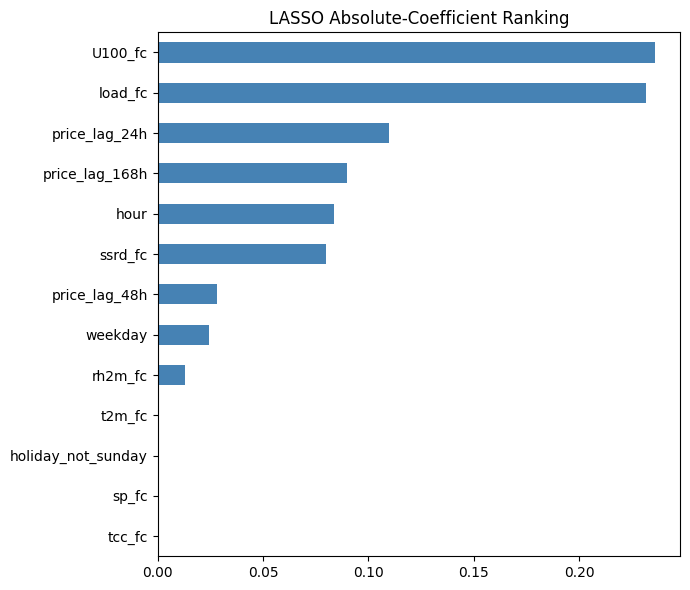

In [8]:
# ── Feature Selection: LASSO Coefficients and Recursive Elimination ────────

# ── Zyklische Feature-Gruppen ──
cyclic_pairs = {
    "hour":    ["hour_sin", "hour_cos"],
    "weekday": ["weekday_sin", "weekday_cos"],
}
single_features = [f for f in FEATURE_COLS if not any(f in pair for pair in cyclic_pairs.values())]
display_names = single_features + list(cyclic_pairs.keys())

col_idx = {f: i for i, f in enumerate(FEATURE_COLS)}

# ── LASSO absolute coefficients ──
lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=1904, n_jobs=-1)
lasso.fit(X_train_base_fs, y_train_base_fs)

raw_lasso = pd.Series(np.abs(lasso.coef_), index=FEATURE_COLS)
lasso_coefs = pd.Series(dtype=float, name="lasso_abs_coef")
for f in single_features:
    lasso_coefs[f] = raw_lasso[f]
for name, cols in cyclic_pairs.items():
    lasso_coefs[name] = np.sqrt((raw_lasso[cols] ** 2).sum())

print("\n── LASSO Absolute-Coefficient Ranking ──")
print(lasso_coefs.sort_values(ascending=False).round(4).to_string())

# ── Visualisation ──
fig, ax = plt.subplots(figsize=(7, 6))
lasso_coefs.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("LASSO Absolute-Coefficient Ranking")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


### Recursive Feature Elimination


Config: default — sklearn defaults
All 13 features → CV-MAE: 0.1563
  Best candidate: 't2m' → CV-MAE: 0.1519  (Δ = -0.0044)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 'rh2m', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 'rh2m' → CV-MAE: 0.1519  (Δ = -0.0000)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 'sp' → CV-MAE: 0.1487  (Δ = -0.0032)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 'tcc' → CV-MAE: 0.1501  (Δ = +0.0015)
    → No improvement. Stopping.
Final features (10): ['load_fc', 'ssrd', 'tcc', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']

Config: deep_slow — {'n_estimators': 300, '

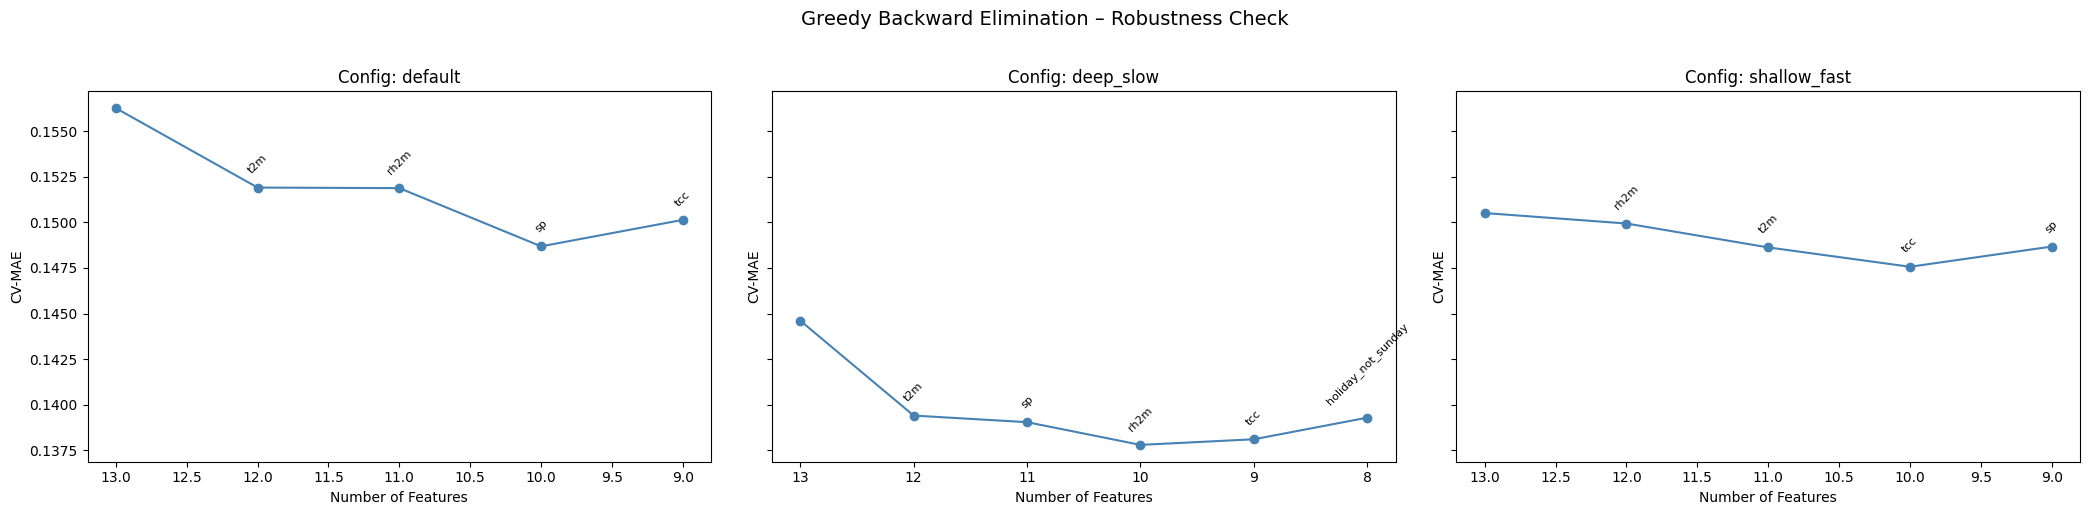

In [ ]:
# ── Greedy Backward Elimination with CV (Multi-Config) ──────────────────────
from sklearn.model_selection import cross_val_score
from collections import Counter

tscv = TimeSeriesSplit(n_splits=5)

def get_col_indices(selected_names):
    indices = []
    for name in selected_names:
        if name in cyclic_pairs:
            indices += [col_idx[col] for col in cyclic_pairs[name]]
        else:
            indices.append(col_idx[name])
    return indices

configs = [
    {"label": "default",      "params": {}},
    {"label": "deep_slow",    "params": {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}},
    {"label": "shallow_fast", "params": {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.1}},
]

all_results = {}

for cfg in configs:
    label = cfg["label"]
    print(f"\n{'='*60}")
    print(f"Config: {label} — {cfg['params'] or 'sklearn defaults'}")
    print(f"{'='*60}")

    def cv_mae_for_features(selected_names):
        idx = get_col_indices(selected_names)
        return -cross_val_score(
            XGBRegressor(
                objective="reg:squarederror", random_state=1904, n_jobs=-1,
                **cfg["params"],
            ),
            X_train_base_fs[:, idx], y_train_base_fs,
            cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1,
        ).mean()

    remaining = display_names.copy()
    current_score = cv_mae_for_features(remaining)
    elimination_log = [{"n_features": len(remaining), "removed": None, "cv_mae": current_score}]
    print(f"All {len(remaining)} features → CV-MAE: {current_score:.4f}")

    while len(remaining) > 1:
        trials = []
        for candidate in remaining:
            trial = [f for f in remaining if f != candidate]
            score = cv_mae_for_features(trial)
            trials.append((candidate, score, trial))

        best_candidate, best_score, best_trial = min(trials, key=lambda x: x[1])
        elimination_log.append({"n_features": len(best_trial), "removed": best_candidate, "cv_mae": best_score})

        print(f"  Best candidate: '{best_candidate}' → CV-MAE: {best_score:.4f}  (Δ = {best_score - current_score:+.4f})")

        if best_score <= current_score * 1.005:
            remaining = best_trial
            current_score = best_score
            print(f"    → Removed. Remaining: {remaining}")
        else:
            print(f"    → No improvement. Stopping.")
            break

    all_results[label] = {
        "remaining": remaining,
        "log": pd.DataFrame(elimination_log),
    }
    print(f"Final features ({len(remaining)}): {remaining}")


# ── Summary: how often was each feature removed? ──

removed_counts = Counter()
for label, result in all_results.items():
    removed_in_config = set(display_names) - set(result["remaining"])
    removed_counts.update(removed_in_config)

print(f"\n{'='*60}")
for f in display_names:
    count = removed_counts.get(f, 0)
    if count > 0:
        print(f"  {f}: removed in {count}/{len(configs)} configs")
print(f"{'='*60}")



# ── Visualization ──
fig, axes = plt.subplots(1, len(configs), figsize=(7 * len(configs), 5), sharey=True)
for ax, (label, result) in zip(axes, all_results.items()):
    log_df = result["log"]
    ax.plot(log_df["n_features"], log_df["cv_mae"], "o-", color="steelblue")
    for _, row in log_df.iterrows():
        if row["removed"]:
            ax.annotate(row["removed"], (row["n_features"], row["cv_mae"]),
                        textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center", rotation=45)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("CV-MAE")
    ax.set_title(f"Config: {label}")
    ax.invert_xaxis()
fig.suptitle("Greedy Backward Elimination – Robustness Check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

*t2m_fc* and *rh2m_fc* are removed in all three recursive-elimination runs, while *tcc_fc* and *sp_fc* are removed in two. These variables also have the lowest absolute LASSO coefficients among the weather variables. Based mainly on the recursive elimination, they are excluded. *U100_fc* and *ssrd_fc* remain as weather-based proxies for wind and solar generation potential.

# Final Modelling Setup / Build Final Datasets

In [8]:
# ---------- Final feature set and modelling datasets ----------

DROP_COLS = ["t2m_fc", "sp_fc", "tcc_fc", "rh2m_fc"]
FEATURE_COLS = [
    col for col in CANDIDATE_FEATURE_COLS
    if col not in DROP_COLS
]
SCALE_COLS = [col for col in SCALE_COLS if col in FEATURE_COLS]
LAG_COLS = [col for col in FEATURE_COLS if col.startswith("price_lag")]
SEQUENCE_COLS = [TARGET_COL]

# Keep the working frames aligned with the final feature set.
model_df = model_df.drop(columns=DROP_COLS, errors="ignore")
for df in SPLIT_FRAMES:
    df.drop(columns=DROP_COLS, errors="ignore", inplace=True)

test_with_history_df = pd.concat([test_history_df, test_df], axis=0)
val_with_history_df = pd.concat([val_history_df, val_df], axis=0)


def _date_ints_from_index(index: pd.DatetimeIndex) -> np.ndarray:
    return np.array(
        [ts.year * 10000 + ts.month * 100 + ts.day for ts in index],
        dtype=np.int32,
    )


# -------------------------------------------------
# Base-Feature Strategy datasets
# -------------------------------------------------
X_train_base, y_train_base, _ = build_base_dataset(
    train_df, FEATURE_COLS, TARGET_COL
)
X_val_base, y_val_base, _ = build_base_dataset(
    val_df, FEATURE_COLS, TARGET_COL
)
X_test_base, y_test_base, _ = build_base_dataset(
    test_df, FEATURE_COLS, TARGET_COL
)

# -------------------------------------------------
# Day-Anchored Lookback Strategy
# -------------------------------------------------
# Fixed price window ending immediately before the local delivery day starts.
# All target hours of the same delivery day share the same price history.

def build_anchored_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp in local delivery day D, the lookback window covers
    the lookback_hours rows ending immediately before D starts. This keeps all
    hours of the same local delivery day on the same day-anchored history window,
    including DST days with 23 or 25 delivery hours.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)
    date_ints = _date_ints_from_index(idx)

    first_pos_by_date = {}
    for pos, date_int in enumerate(date_ints):
        first_pos_by_date.setdefault(date_int, pos)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(len(df)):
        day_start_pos = first_pos_by_date[date_ints[row_idx]]
        keep_idx = np.arange(day_start_pos - lookback_hours, day_start_pos)
        if keep_idx[0] < 0:
            continue
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )

# Build the final day-anchored datasets.
X_train_seq_anchored, X_train_exog_anchored, y_train_anchored, _ = build_anchored_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK
)
X_val_seq_anchored, X_val_exog_anchored, y_val_anchored, _ = build_anchored_dataset(
    val_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK
)
X_test_seq_anchored, X_test_exog_anchored, y_test_anchored, _ = build_anchored_dataset(
    test_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK
)


def flatten_lookback_inputs(X_seq, X_exog):
    return np.concatenate(
        [X_seq.reshape(X_seq.shape[0], -1), X_exog],
        axis=1,
    )


X_train_flat_anchored = flatten_lookback_inputs(
    X_train_seq_anchored, X_train_exog_anchored
)
X_val_flat_anchored = flatten_lookback_inputs(
    X_val_seq_anchored, X_val_exog_anchored
)
X_test_flat_anchored = flatten_lookback_inputs(
    X_test_seq_anchored, X_test_exog_anchored
)

display(pd.DataFrame([
    {"set": "Base-Feature Strategy", "split": "train", "X": X_train_base.shape, "y": y_train_base.shape},
    {"set": "Base-Feature Strategy", "split": "val", "X": X_val_base.shape, "y": y_val_base.shape},
    {"set": "Base-Feature Strategy", "split": "test", "X": X_test_base.shape, "y": y_test_base.shape},
]))
display(pd.DataFrame([
    {"set": "Day-Anchored Lookback Strategy", "split": "train", "X_seq": X_train_seq_anchored.shape, "X_exog": X_train_exog_anchored.shape, "X_flat": X_train_flat_anchored.shape, "y": y_train_anchored.shape},
    {"set": "Day-Anchored Lookback Strategy", "split": "val", "X_seq": X_val_seq_anchored.shape, "X_exog": X_val_exog_anchored.shape, "X_flat": X_val_flat_anchored.shape, "y": y_val_anchored.shape},
    {"set": "Day-Anchored Lookback Strategy", "split": "test", "X_seq": X_test_seq_anchored.shape, "X_exog": X_test_exog_anchored.shape, "X_flat": X_test_flat_anchored.shape, "y": y_test_anchored.shape},
]))


# -------------------------------------------------
# Recursive Rolling-Lookback Strategy
# -------------------------------------------------
# Rolling window ending one hour before the target timestamp.
# Models for this strategy are trained on the same rolling-window layout.
# During recursive evaluation, same-day target values are replaced by earlier predictions.

ROLLING_PRICE_COL = "_rolling_price"


def to_numpy_float32(values) -> np.ndarray:
    if hasattr(values, "to_numpy"):
        values = values.to_numpy()
    if hasattr(values, "get"):
        values = values.get()
    return np.asarray(values, dtype=np.float32).reshape(-1)


def _steps_within_day(index: pd.DatetimeIndex) -> np.ndarray:
    date_ints = _date_ints_from_index(index)
    steps = np.empty(len(index), dtype=np.int32)
    previous_date = None
    step = -1

    for i, date_int in enumerate(date_ints):
        if date_int != previous_date:
            previous_date = date_int
            step = 0
        else:
            step += 1
        steps[i] = step

    return steps


def build_rolling_training_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp ts, the sequence covers the last `lookback_hours`
    rows ending at ts - 1h. This is the training layout used by the recursive rolling-lookback models.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(lookback_hours, len(df)):
        keep_idx = np.arange(row_idx - lookback_hours, row_idx)
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )


def build_rolling_frame(
    history_df: pd.DataFrame,
    target_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> pd.DataFrame:
    rolling = pd.concat(
        [
            history_df[[target_col]],
            target_df[[target_col] + feature_cols],
        ],
        axis=0,
    ).sort_index()

    if not rolling.index.is_unique:
        raise ValueError("rolling_df index must be unique.")
    if rolling[target_col].isna().any():
        raise ValueError("rolling_df target contains missing values.")

    rolling[ROLLING_PRICE_COL] = rolling[target_col].astype(np.float32)
    rolling.loc[target_df.index, ROLLING_PRICE_COL] = np.nan
    return rolling


def _rolling_predict(
    rolling_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    predict_batch,
    verbose: bool = False,
) -> np.ndarray:
    target_times = pd.DatetimeIndex(target_times)
    if len(target_times) == 0:
        return np.array([], dtype=np.float32)
    if not target_times.is_monotonic_increasing:
        raise ValueError("target_times must be sorted increasingly for recursive rolling prediction.")

    idx_lookup = {ts: i for i, ts in enumerate(rolling_df.index)}
    missing_times = [ts for ts in target_times if ts not in idx_lookup]
    if missing_times:
        raise KeyError(f"target timestamp missing from rolling_df: {missing_times[0]}")

    target_pos = np.array([idx_lookup[ts] for ts in target_times], dtype=np.int64)
    if np.any(target_pos < lookback_hours):
        raise ValueError("rolling_df does not contain enough history for the requested lookback.")

    rolling_price = rolling_df[ROLLING_PRICE_COL].to_numpy(dtype=np.float32).copy()
    target_arr = rolling_df[target_col].to_numpy(dtype=np.float32)
    exog_arr = rolling_df[feature_cols].to_numpy(dtype=np.float32)
    date_ints = _date_ints_from_index(rolling_df.index)
    target_date_ints = _date_ints_from_index(target_times)
    target_steps = _steps_within_day(target_times)

    preds = np.zeros(len(target_times), dtype=np.float32)
    lookback_offsets = np.arange(-lookback_hours, 0, dtype=np.int64)
    max_step = int(target_steps.max())

    for step in range(max_step + 1):
        band = np.flatnonzero(target_steps == step)
        if len(band) == 0:
            continue

        pos = target_pos[band]
        hist_pos = pos[:, None] + lookback_offsets
        same_day = date_ints[hist_pos] == target_date_ints[band, None]

        seq = np.where(same_day, rolling_price[hist_pos], target_arr[hist_pos]).astype(np.float32)
        if np.isnan(seq).any():
            raise ValueError(
                "Recursive rolling sequence contains NaN. target_times must include previous same-day targets."
            )
        exog = exog_arr[pos].astype(np.float32)

        y_hat = to_numpy_float32(predict_batch(seq, exog))
        if len(y_hat) != len(band):
            raise ValueError("Recursive rolling model returned an unexpected number of predictions.")

        preds[band] = y_hat
        rolling_price[pos] = y_hat

        if verbose:
            print(f"  Recursive rolling step {step + 1:02d}/{max_step + 1:02d} - {len(band)} samples")

    return preds


def rolling_predict_tabular(
    model,
    rolling_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    verbose: bool = False,
) -> np.ndarray:
    def predict_batch(seq: np.ndarray, exog: np.ndarray):
        x_batch = np.concatenate([seq, exog], axis=1).astype(np.float32)
        return model.predict(x_batch)

    return _rolling_predict(
        rolling_df,
        target_times,
        feature_cols,
        target_col,
        lookback_hours,
        predict_batch,
        verbose=verbose,
    )


def rolling_predict_keras(
    model,
    rolling_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    verbose: bool = False,
) -> np.ndarray:
    def predict_batch(seq: np.ndarray, exog: np.ndarray):
        keras_inputs = [seq[:, :, None], exog]
        try:
            return model.predict(keras_inputs, verbose=0)
        except TypeError:
            return model.predict(keras_inputs)

    return _rolling_predict(
        rolling_df,
        target_times,
        feature_cols,
        target_col,
        lookback_hours,
        predict_batch,
        verbose=verbose,
    )



# --- build Recursive Rolling-Lookback Strategy training data ---
X_train_seq_rolling, X_train_exog_rolling, y_train_rolling, ts_train_rolling = build_rolling_training_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)
X_train_flat_rolling = flatten_lookback_inputs(
    X_train_seq_rolling, X_train_exog_rolling
)

# Validation and test inputs for the Recursive Rolling-Lookback Strategy are generated recursively.
ts_val_rolling = val_with_history_df.index[LOOKBACK:]
ts_test_rolling = test_with_history_df.index[LOOKBACK:]

rolling_df_val = build_rolling_frame(val_history_df, val_df, FEATURE_COLS, TARGET_COL)
val_rolling_index = ts_val_rolling
y_val_rolling = y_val

rolling_df = build_rolling_frame(test_history_df, test_df, FEATURE_COLS, TARGET_COL)
test_rolling_index = ts_test_rolling
y_test_rolling = y_test

display(pd.DataFrame([
    {"set": "Recursive Rolling-Lookback Strategy", "split": "train", "X_seq": X_train_seq_rolling.shape, "X_exog": X_train_exog_rolling.shape, "X_flat": X_train_flat_rolling.shape, "y": y_train_rolling.shape},
]))

,set,split,X,y
0,Base-Feature Strategy,train,"(17544, 11)","(17544,)"
1,Base-Feature Strategy,val,"(4343, 11)","(4343,)"
2,Base-Feature Strategy,test,"(4417, 11)","(4417,)"


,set,split,X_seq,X_exog,X_flat,y
0,Day-Anchored Lookback Strategy,train,"(17496, 48, 1)","(17496, 11)","(17496, 59)","(17496,)"
1,Day-Anchored Lookback Strategy,val,"(4343, 48, 1)","(4343, 11)","(4343, 59)","(4343,)"
2,Day-Anchored Lookback Strategy,test,"(4417, 48, 1)","(4417, 11)","(4417, 59)","(4417,)"


,set,split,X_seq,X_exog,X_flat,y
0,Recursive Rolling-Lookback Strategy,train,"(17496, 48, 1)","(17496, 11)","(17496, 59)","(17496,)"


# Modelling

## First Training

### Naive Benchmarks

In [ ]:
# -------------------------------------------------
# Naive benchmark variants (raw EUR/MWh, no transformation)
#   naive_24h    : price of the same hour on the previous day      p(d-1, h)
#   naive_168h   : price of the same hour one week earlier         p(d-7, h)
#   naive_similar: p(d-1, h) on Tue-Fri, p(d-7, h) on Sat/Sun/Mon
# -------------------------------------------------

# `data` still holds the untransformed prices and lag columns.
is_tue_to_fri = data.index.dayofweek.isin([1, 2, 3, 4])   # Mon=0 ... Sun=6

naive_forecasts = pd.DataFrame(
    {
        "naive_24h": data["price_lag_24h"],
        "naive_168h": data["price_lag_168h"],
        "naive_similar": np.where(
            is_tue_to_fri, data["price_lag_24h"], data["price_lag_168h"]
        ),
    },
    index=data.index,
)
naive_forecasts["actual"] = data[TARGET_COL]

# The lag features are built before the dataset is truncated to 2023-2025, so the
# 168h lag is already available for the first delivery hour of 2023. All three
# variants are therefore evaluated on the same observations.

naive_rows = []
for split_name, (start, end) in {
    "train": (TRAIN_START, TRAIN_END),
    "val": (VAL_START, VAL_END),
}.items():
    part = naive_forecasts[
        (naive_forecasts.index >= start) & (naive_forecasts.index < end)
    ]
    for variant in ["naive_24h", "naive_168h", "naive_similar"]:
        naive_rows.append(
            {
                "naive variant": variant,
                "split": split_name,
                "mae": mae_score(part["actual"], part[variant]),
                "rmse": rmse_score(part["actual"], part[variant]),
            }
        )

naive_scores = (
    pd.DataFrame(naive_rows)
    .pivot(index="naive variant", columns="split", values=["mae", "rmse"])
    .swaplevel(axis=1)
    .reindex(columns=pd.MultiIndex.from_product([["train", "val"], ["mae", "rmse"]]))
    .loc[["naive_24h", "naive_168h", "naive_similar"]]
)
naive_scores.columns.names = ["split", None]

display(naive_scores.round(3))

split           train             val        
                  mae    rmse     mae    rmse
naive variant                                
naive_24h     27.5150 42.3480 27.4790 41.6530
naive_168h    33.2220 51.8640 35.1060 50.4220
naive_similar 27.9530 43.3140 28.9010 44.6880

### XGBoost




In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
xgb_common_params = dict(
    objective="reg:squarederror",
    random_state=1904,
    n_jobs=-1,
    device="cuda"
)

xgb_param_dist = {
    "n_estimators": [100, 200, 400, 500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "min_child_weight": [1, 3, 5, 7],
}

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# -------------------------------------------------
# Base-Feature Strategy model tuning
# -------------------------------------------------
search_base = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_common_params),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_base.fit(X_train_base, y_train_base)
xgb_base = search_base.best_estimator_

print("Best params (Base-Feature Strategy):", search_base.best_params_)
print("Best CV score (Base-Feature Strategy):", -search_base.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [06:45:27] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params (Base-Feature Strategy): {'subsample': 0.6, 'reg_lambda': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV score (Base-Feature Strategy): 0.1355477452278137


In [ ]:
# -------------------------------------------------
# Day-Anchored Lookback Strategy model tuning
# -------------------------------------------------
search_anchored = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_common_params),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_anchored.fit(X_train_flat_anchored, y_train_anchored)
xgb_anchored = search_anchored.best_estimator_

print("Best params (Day-Anchored Lookback Strategy):", search_anchored.best_params_)
print("Best CV score (Day-Anchored Lookback Strategy):", -search_anchored.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [13:52:43] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params (Day-Anchored Lookback Strategy): {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV score (Day-Anchored Lookback Strategy): 0.12572363317012786


In [ ]:
# -------------------------------------------------
# Recursive Rolling-Lookback Strategy model tuning
# -------------------------------------------------
search_rolling = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_common_params),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rolling.fit(X_train_flat_rolling, y_train_rolling)
xgb_rolling = search_rolling.best_estimator_

print("Best params (Recursive Rolling-Lookback Strategy):", search_rolling.best_params_)
print("Best CV score (Recursive Rolling-Lookback Strategy):", -search_rolling.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (Recursive Rolling-Lookback Strategy): {'subsample': 0.6, 'reg_lambda': 2.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV score (Recursive Rolling-Lookback Strategy): 0.05632321909070015


In [ ]:
# save XGBoost models in the version-stable UBJSON format
xgb_base.save_model("models/xgb_base.ubj")
xgb_anchored.save_model("models/xgb_anchored.ubj")
xgb_rolling.save_model("models/xgb_rolling.ubj")

['models/xgb_rolling_model.joblib']

### Random Forest


In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
from cuml.ensemble import RandomForestRegressor as RFRegressor

rf_common_params = dict(random_state=1904)

rf_param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [8, 12, 16, 20, 32],
    "max_features":      [0.33, 0.5, "sqrt"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_samples":       [0.6, 0.8, 1.0],        # bootstrap fraction
}

tscv = TimeSeriesSplit(n_splits=5)


In [ ]:
# -------------------------------------------------
# Base-Feature Strategy model tuning
# -------------------------------------------------
search_rf_base = RandomizedSearchCV(
    estimator=RFRegressor(**rf_common_params),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1
)

search_rf_base.fit(X_train_base, y_train_base)
rf_base = search_rf_base.best_estimator_

print("Best params (RF Base-Feature Strategy):", search_rf_base.best_params_)
print("Best CV MAE  (RF Base-Feature Strategy):", -search_rf_base.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF Base-Feature Strategy): {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 1.0, 'max_features': 0.33, 'max_depth': 12}
Best CV MAE  (RF Base-Feature Strategy): 0.14083043932914735


In [ ]:
# -------------------------------------------------
# Day-Anchored Lookback Strategy model tuning
# -------------------------------------------------
search_rf_anchored = RandomizedSearchCV(
    estimator=RFRegressor(**rf_common_params),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_anchored.fit(X_train_flat_anchored, y_train_anchored)
rf_anchored = search_rf_anchored.best_estimator_

print("Best params (RF Day-Anchored Lookback Strategy):", search_rf_anchored.best_params_)
print("Best CV MAE  (RF Day-Anchored Lookback Strategy):", -search_rf_anchored.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF Day-Anchored Lookback Strategy): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20}
Best CV MAE  (RF Day-Anchored Lookback Strategy): 0.13599431216716767


In [ ]:
# -------------------------------------------------
# Recursive Rolling-Lookback Strategy model tuning
# -------------------------------------------------
search_rf_rolling = RandomizedSearchCV(
    estimator=RFRegressor(**rf_common_params),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_rolling.fit(X_train_flat_rolling, y_train_rolling)
rf_rolling = search_rf_rolling.best_estimator_

print("Best params (RF Recursive Rolling-Lookback Strategy):", search_rf_rolling.best_params_)
print("Best CV MAE  (RF Recursive Rolling-Lookback Strategy):", -search_rf_rolling.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF Recursive Rolling-Lookback Strategy): {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_samples': 1.0, 'max_features': 0.5, 'max_depth': 32}
Best CV MAE  (RF Recursive Rolling-Lookback Strategy): 0.06182406097650528


In [ ]:
# save models
joblib.dump(rf_base, "models/rf_base.joblib")
joblib.dump(rf_anchored, "models/rf_anchored.joblib")
joblib.dump(rf_rolling, "models/rf_rolling.joblib")

['models/rf_rolling_model.joblib']

### Support Vector Machine


In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
from cuml.svm import SVR as SVRModel

svm_param_dist = {
    "C":       [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.05, 0.1, 0.5, 1.0],
    "gamma":   ["scale", "auto", 0.001, 0.01, 0.1],
}

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# -------------------------------------------------
# Base-Feature Strategy model tuning
# -------------------------------------------------
search_svm_base = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)
search_svm_base.fit(X_train_base, y_train_base)

svm_base = search_svm_base.best_estimator_

print("Best params (SVM Base-Feature Strategy):", search_svm_base.best_params_)
print("Best CV MAE  (SVM Base-Feature Strategy):", -search_svm_base.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM Base-Feature Strategy): {'gamma': 'auto', 'epsilon': 0.05, 'C': 1}
Best CV MAE  (SVM Base-Feature Strategy): 0.14339711219072343


In [ ]:
# -------------------------------------------------
# Day-Anchored Lookback Strategy model tuning
# -------------------------------------------------
search_svm_anchored = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_anchored.fit(X_train_flat_anchored, y_train_anchored)
svm_anchored = search_svm_anchored.best_estimator_

print("Best params (SVM Day-Anchored Lookback Strategy):", search_svm_anchored.best_params_)
print("Best CV MAE  (SVM Day-Anchored Lookback Strategy):", -search_svm_anchored.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM Day-Anchored Lookback Strategy): {'gamma': 0.01, 'epsilon': 0.01, 'C': 1}
Best CV MAE  (SVM Day-Anchored Lookback Strategy): 0.13802863657474518


In [ ]:
# -------------------------------------------------
# Recursive Rolling-Lookback Strategy model tuning
# -------------------------------------------------
search_svm_rolling = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_rolling.fit(X_train_flat_rolling, y_train_rolling)
svm_rolling = search_svm_rolling.best_estimator_

print("Best params (SVM Recursive Rolling-Lookback Strategy):", search_svm_rolling.best_params_)
print("Best CV MAE  (SVM Recursive Rolling-Lookback Strategy):", -search_svm_rolling.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM Recursive Rolling-Lookback Strategy): {'gamma': 0.001, 'epsilon': 0.05, 'C': 100}
Best CV MAE  (SVM Recursive Rolling-Lookback Strategy): 0.05668566972017288


In [ ]:
joblib.dump(svm_base, "models/svm_base.joblib")
joblib.dump(svm_anchored, "models/svm_anchored.joblib")
joblib.dump(svm_rolling, "models/svm_rolling.joblib")

['models/svm_rolling_model.joblib']

###  LSTM




In [ ]:
# -------------------------------------------------
# LSTM builder
# -------------------------------------------------
def build_lstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_anchored.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_anchored.shape[1],))

    hidden = layers.LSTM(
        units=int(params["lstm_units"]),
        dropout=float(params["lstm_dropout"]),
        recurrent_dropout=float(params["recurrent_dropout"]),
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation with last 15% of train as validation set
# -------------------------------------------------
def evaluate_lstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=40,
    patience=6,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_lstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
param_dist = {
    "lstm_units": [32, 64, 96, 128],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [64, 128],
}


# -------------------------------------------------
# Manual random search for the Day-Anchored and Recursive Rolling-Lookback Strategies
# -------------------------------------------------
n_trials = 30
lstm_search_space = list(ParameterSampler(param_dist, n_iter=n_trials, random_state=1904))

results = []
rolling_results = []

print(f"Starte LSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(lstm_search_space, start=1):
    print(f"[{i}/{n_trials}] Day-Anchored Strategy teste: {params}")

    scores = evaluate_lstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_anchored,
        X_exog=X_train_exog_anchored,
        y=y_train_anchored,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    results.append(row)

    print(
        f"    -> Day-Anchored Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

for i, params in enumerate(lstm_search_space, start=1):
    print(f"[{i}/{n_trials}] Recursive Rolling Strategy teste: {params}")

    scores = evaluate_lstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_rolling,
        X_exog=X_train_exog_rolling,
        y=y_train_rolling,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    rolling_results.append(row)

    print(
        f"    -> Recursive Rolling Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

rolling_results_df = (
    pd.DataFrame(rolling_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(results_df.head(5))
display(rolling_results_df.head(5))

best_params = {k: results_df.loc[0, k] for k in param_dist.keys()}
best_rolling_params = {k: rolling_results_df.loc[0, k] for k in param_dist.keys()}

print("\nBeste LSTM-Hyperparameter (Day-Anchored Lookback Strategy):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

print("\nBeste LSTM-Hyperparameter (Recursive Rolling-Lookback Strategy):")
for k, v in best_rolling_params.items():
    print(f"  {k}: {v}")

Starte LSTM Hyperparameter-Suche (30 Trials, Holdout 15%) ...
[1/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 64, 'lstm_dropout': 0.0, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.4, 'batch_size': 128}
    -> Day-Anchored Val-MAE_t: 0.1514 | Val-RMSE_t: 0.2096 | Epochs: 15
[2/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 96, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 32, 'dense_dropout': 0.0, 'batch_size': 128}
    -> Day-Anchored Val-MAE_t: 0.1486 | Val-RMSE_t: 0.2141 | Epochs: 12
[3/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 128, 'lstm_dropout': 0.0, 'learning_rate': 0.003, 'dense_units': 32, 'dense_dropout': 0.2, 'batch_size': 64}
    -> Day-Anchored Val-MAE_t: 0.1343 | Val-RMSE_t: 0.1950 | Epochs: 14
[4/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.1, 'learning_rate': 0.003, 'dense_units': 32, 'dense_dropout': 0.0, 'batch_size': 128}
    -> Day-Anchored Val-MAE_t:

,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,128,0.0000,0.0030,128,0.4000,128,0.1304,0.1943,14
1,0.0000,64,0.2000,0.0030,64,0.3000,128,0.1321,0.1915,16
2,0.0000,96,0.1000,0.0010,128,0.3000,64,0.1332,0.1951,27
3,0.0000,128,0.0000,0.0010,64,0.3000,64,0.1337,0.1927,17
4,0.0000,128,0.0000,0.0030,32,0.2000,64,0.1343,0.1950,14


,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,96,0.0000,0.0003,32,0.1000,64,0.0619,0.0949,40
1,0.0000,128,0.0000,0.0010,64,0.3000,64,0.0630,0.0964,40
2,0.0000,128,0.0000,0.0030,128,0.4000,128,0.0648,0.0977,31
3,0.0000,32,0.0000,0.0030,128,0.4000,128,0.0663,0.0986,34
4,0.0000,64,0.0000,0.0010,32,0.4000,64,0.0666,0.1006,34



Beste LSTM-Hyperparameter (Day-Anchored Lookback Strategy):
  lstm_units: 128
  dense_units: 128
  lstm_dropout: 0.0
  dense_dropout: 0.4
  recurrent_dropout: 0.0
  learning_rate: 0.003
  batch_size: 128

Beste LSTM-Hyperparameter (Recursive Rolling-Lookback Strategy):
  lstm_units: 96
  dense_units: 32
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.0003
  batch_size: 64


In [ ]:
# -------------------------------------------------
# Final fit
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

lstm_anchored = build_lstm(best_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_anchored.fit(
    [X_train_seq_anchored, X_train_exog_anchored],
    y_train_anchored,
    validation_split=0.15,
    epochs=40,
    batch_size=int(best_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

# Separate Recursive Rolling-Lookback Strategy model with strategy-specific tuned hyperparameters.
tf.keras.utils.set_random_seed(1904)
lstm_rolling = build_lstm(best_rolling_params)

early_stop_rolling = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_rolling.fit(
    [X_train_seq_rolling, X_train_exog_rolling],
    y_train_rolling,
    validation_split=0.15,
    epochs=40,
    batch_size=int(best_rolling_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rolling],
    verbose=1,
)


Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2360 - rmse: 0.3170 - val_loss: 0.1716 - val_rmse: 0.2267
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1736 - rmse: 0.2267 - val_loss: 0.1569 - val_rmse: 0.2089
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1587 - rmse: 0.2093 - val_loss: 0.1489 - val_rmse: 0.2047
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1529 - rmse: 0.2016 - val_loss: 0.1507 - val_rmse: 0.2039
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1469 - rmse: 0.1952 - val_loss: 0.1378 - val_rmse: 0.1959
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1451 - rmse: 0.1943 - val_loss: 0.1402 - val_rmse: 0.2003
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1432 - rmse: 0.1925 - val_loss: 0.1355 - val_rmse: 0.1958
Epoch 8/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1390 - rmse: 0.1886 - val_loss: 0.1310 - val_rmse: 0.1938
Epoch 9/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# save lstm models
joblib.dump(lstm_anchored, "models/lstm_anchored.joblib")
joblib.dump(lstm_rolling, "models/lstm_rolling.joblib")

['models/lstm_rolling_model.joblib']

###  BiLSTM

In [ ]:
# -------------------------------------------------
# BiLSTM builder
# -------------------------------------------------
def build_bilstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_anchored.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_anchored.shape[1],))

    hidden = layers.Bidirectional(
        layers.LSTM(
            units=int(params["lstm_units"]),
            dropout=float(params["lstm_dropout"]),
            recurrent_dropout=float(params["recurrent_dropout"]),
        )
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation with last 15% of train as validation set
# -------------------------------------------------
def evaluate_bilstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=40,
    patience=6,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_bilstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
bilstm_param_dist = {
    "lstm_units": [32, 48, 64, 96],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.1, 0.2, 0.3],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 5e-4, 1e-3, 2e-3],
    "batch_size": [32, 64],
}


# -------------------------------------------------
# Manual random search for the Day-Anchored and Recursive Rolling-Lookback Strategies
# -------------------------------------------------
n_trials = 30
bilstm_search_space = list(ParameterSampler(bilstm_param_dist, n_iter=n_trials, random_state=1904))

bilstm_anchored_results = []
bilstm_rolling_results = []

print(f"Starte BiLSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(bilstm_search_space, start=1):
    print(f"[{i}/{n_trials}] Day-Anchored Strategy teste: {params}")

    scores = evaluate_bilstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_anchored,
        X_exog=X_train_exog_anchored,
        y=y_train_anchored,
        val_frac=0.15,
        epochs=50,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    bilstm_anchored_results.append(row)

    print(
        f"    -> Day-Anchored Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

for i, params in enumerate(bilstm_search_space, start=1):
    print(f"[{i}/{n_trials}] Recursive Rolling Strategy teste: {params}")

    scores = evaluate_bilstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_rolling,
        X_exog=X_train_exog_rolling,
        y=y_train_rolling,
        val_frac=0.15,
        epochs=50,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    bilstm_rolling_results.append(row)

    print(
        f"    -> Recursive Rolling Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

bilstm_anchored_results_df = (
    pd.DataFrame(bilstm_anchored_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

bilstm_rolling_results_df = (
    pd.DataFrame(bilstm_rolling_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(bilstm_anchored_results_df.head(5))
display(bilstm_rolling_results_df.head(5))

best_bilstm_anchored_params = {k: bilstm_anchored_results_df.loc[0, k] for k in bilstm_param_dist.keys()}
best_bilstm_rolling_params = {k: bilstm_rolling_results_df.loc[0, k] for k in bilstm_param_dist.keys()}

print("\nBeste BiLSTM-Hyperparameter (Day-Anchored Lookback Strategy):")
for k, v in best_bilstm_anchored_params.items():
    print(f"  {k}: {v}")

print("\nBeste BiLSTM-Hyperparameter (Recursive Rolling-Lookback Strategy):")
for k, v in best_bilstm_rolling_params.items():
    print(f"  {k}: {v}")

Starte BiLSTM Hyperparameter-Suche (30 Trials, Holdout 15%) ...
[1/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 96, 'lstm_dropout': 0.0, 'learning_rate': 0.0003, 'dense_units': 32, 'dense_dropout': 0.1, 'batch_size': 64}
    -> Day-Anchored Val-MAE_t: 0.1442 | Val-RMSE_t: 0.2034 | Epochs: 16
[2/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 128, 'dense_dropout': 0.2, 'batch_size': 32}
    -> Day-Anchored Val-MAE_t: 0.1371 | Val-RMSE_t: 0.1950 | Epochs: 14
[3/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.002, 'dense_units': 128, 'dense_dropout': 0.1, 'batch_size': 64}
    -> Day-Anchored Val-MAE_t: 0.1385 | Val-RMSE_t: 0.1947 | Epochs: 28
[4/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 64, 'lstm_dropout': 0.0, 'learning_rate': 0.002, 'dense_units': 32, 'dense_dropout': 0.1, 'batch_size': 32}
    -> Day-Anchored Val-MAE_t

,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,64,0.0000,0.0020,32,0.1000,32,0.1265,0.1826,28
1,0.0000,48,0.0000,0.0010,64,0.2000,32,0.1300,0.1879,42
2,0.0000,64,0.2000,0.0020,64,0.3000,64,0.1308,0.1889,20
3,0.0000,32,0.0000,0.0020,32,0.1000,32,0.1309,0.1880,35
4,0.0000,48,0.1000,0.0020,64,0.3000,32,0.1310,0.1886,27


,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,96,0.0000,0.0003,64,0.1000,64,0.0630,0.0958,50
1,0.0000,32,0.0000,0.0020,32,0.1000,32,0.0666,0.1027,25
2,0.0000,96,0.0000,0.0003,32,0.1000,64,0.0670,0.1008,35
3,0.0000,96,0.0000,0.0003,64,0.3000,32,0.0686,0.1007,20
4,0.0000,64,0.0000,0.0010,128,0.3000,64,0.0686,0.1016,16



Beste BiLSTM-Hyperparameter (Day-Anchored Lookback Strategy):
  lstm_units: 64
  dense_units: 32
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.002
  batch_size: 32

Beste BiLSTM-Hyperparameter (Recursive Rolling-Lookback Strategy):
  lstm_units: 96
  dense_units: 64
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.0003
  batch_size: 64


In [ ]:
# -------------------------------------------------
# Final fit
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

bilstm_anchored = build_bilstm(best_bilstm_anchored_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_anchored.fit(
    [X_train_seq_anchored, X_train_exog_anchored],
    y_train_anchored,
    validation_split=0.15,
    epochs=50,
    batch_size=int(best_bilstm_anchored_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

# Separate Recursive Rolling-Lookback Strategy model with strategy-specific tuned hyperparameters.
tf.keras.utils.set_random_seed(1904)
bilstm_rolling = build_bilstm(best_bilstm_rolling_params)

early_stop_rolling = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_rolling.fit(
    [X_train_seq_rolling, X_train_exog_rolling],
    y_train_rolling,
    validation_split=0.15,
    epochs=50,
    batch_size=int(best_bilstm_rolling_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rolling],
    verbose=1,
)


Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2025 - rmse: 0.2808 - val_loss: 0.1438 - val_rmse: 0.2006
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1524 - rmse: 0.2043 - val_loss: 0.1403 - val_rmse: 0.1966
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1420 - rmse: 0.1907 - val_loss: 0.1388 - val_rmse: 0.1906
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1359 - rmse: 0.1851 - val_loss: 0.1376 - val_rmse: 0.1920
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1312 - rmse: 0.1797 - val_loss: 0.1343 - val_rmse: 0.1882
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1273 - rmse: 0.1756 - val_loss: 0.1357 - val_rmse: 0.1870
Epoch 7/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1246 - rmse: 0.1730 - val_loss: 0.1330 - val_rmse: 0.1875
Epoch 8/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1242 - rmse: 0.1726 - val_loss: 0.1348 - val_rmse: 0.1861
Epoch 9/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
joblib.dump(bilstm_anchored, "models/bilstm_anchored.joblib")
joblib.dump(bilstm_rolling, "models/bilstm_rolling.joblib")

['models/bilstm_rolling_model.joblib']

### SARIMAX

In [ ]:
# ── Simple pre-diagnostic: decide differencing + derive a compact grid ──
# Decide HOW OFTEN to difference (d, D) from the data.
# The exact AR/MA orders (p, q, P, Q) are left to the AIC grid search,
# but deliberately restricted to small values.

from statsmodels.tsa.stattools import adfuller, kpss

S = 24  # daily seasonality for hourly data
y = train_df[TARGET_COL]


def is_stationary(series):
    """A series counts as stationary only if ADF AND KPSS agree."""
    adf_p = adfuller(series.dropna())[1]              # H0: non-stationary -> p < 0.05 = stationary
    kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary
    return (adf_p < 0.05) and (kpss_p > 0.05), adf_p, kpss_p


# Decide differencing: seasonal first (against the daily pattern), then regular if needed.
stat_orig, adf0, kpss0 = is_stationary(y)
stat_seas, adf1, kpss1 = is_stationary(y.diff(S).dropna())

d, D = 0, 0
if not stat_orig:
    D = 1                 # seasonal differencing against the daily seasonality
    if not stat_seas:
        d = 1             # additional regular differencing if still not stationary

print(f"Original     : stationary={stat_orig}  (ADF p={adf0:.3f}, KPSS p={kpss0:.3f})")
print(f"Seasonal diff: stationary={stat_seas}  (ADF p={adf1:.3f}, KPSS p={kpss1:.3f})")
print(f"=> chosen differencing: d={d}, D={D}, s={S}\n")

# Compact grid for the AR/MA orders.
sarimax_search_space = sorted(
    (p, q, P, Q)
    for p, q, P, Q in product([0, 1, 2], [0, 1, 2], [0, 1], [0, 1])    # initial grid with common sense limits to avoid long runtimes
    if (p + q) <= 2 and (P + Q) <= 2                                   # keep the model lean (no overfitting) by limiting total AR+MA orders
    and not ((p >= 2 and P >= 1) or (q >= 2 and Q >= 1))               # avoid known over-parameterization patterns (high non-seasonal + seasonal orders together
)

print(f"Search grid: d={d}, D={D}, s={S}, {len(sarimax_search_space)} candidates (p,q,P,Q):")
print(sarimax_search_space)


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_80390/1764809939.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary


Original     : stationary=False  (ADF p=0.000, KPSS p=0.010)
Seasonal diff: stationary=True  (ADF p=0.000, KPSS p=0.100)
=> chosen differencing: d=0, D=1, s=24

Search grid: d=0, D=1, s=24, 20 candidates (p,q,P,Q):
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 1, 0), (0, 0, 1, 1), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 1, 1, 1), (0, 2, 0, 0), (0, 2, 1, 0), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 0, 1, 1), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (1, 1, 1, 1), (2, 0, 0, 0), (2, 0, 0, 1)]


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_80390/1764809939.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary


In [ ]:
# -------------------------------------------------
# Hyperparameter tuning (AIC grid search)
# -------------------------------------------------

sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train  = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

RESULTS_PATH = "data/sarimax_gridsearch_results.csv"

# Resume: load existing results
if os.path.exists(RESULTS_PATH):
    candidates = pd.read_csv(RESULTS_PATH).to_dict("records")
    done_keys = {(int(r["p"]), int(r["q"]), int(r["P"]), int(r["Q"])) for r in candidates}
    print(f"Resuming: {len(done_keys)}/{len(sarimax_search_space)} candidates already done.")
else:
    candidates = []
    done_keys = set()

for i, (p, q, P, Q) in enumerate(sarimax_search_space):
    tag = f"({p},0,{q})({P},1,{Q},24)"
    if (p, q, P, Q) in done_keys:
        print(f"[{i+1}/{len(sarimax_search_space)}] {tag}  skipped (done)")
        continue
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            m = SARIMAX(
                endog=sarimax_endog_train,
                exog=sarimax_exog_train,
                order=(p, d, q),
                seasonal_order=(P, D, Q, S),
                trend="n",
            ).fit(disp=False, maxiter=100, method="lbfgs")

        rv = m.mle_retvals
        warn_names = sorted({w.category.__name__ for w in caught})
        candidates.append({
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": m.aic, "bic": m.bic,
            "converged": rv.get("converged"),
            "warnflag":  rv.get("warnflag"),
            "warnings":  "; ".join(warn_names),
        })
        done_keys.add((p, q, P, Q))
        pd.DataFrame(candidates).to_csv(RESULTS_PATH, index=False)

        print(f"[{i+1}/{len(sarimax_search_space)}] {tag}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
              f"converged={rv.get('converged')}")
        for w in caught:
            print(f"        \u26a0 {w.category.__name__}: {str(w.message).splitlines()[0]}")

    except Exception as e:
        print(f"[{i+1}/{len(sarimax_search_space)}] {tag}  FAILED: {e}")

tuning_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
print("\nTop 5 candidates:")
print(tuning_df.head(5))

best = tuning_df.iloc[0]
SARIMAX_ORDER    = (int(best["p"]), 0, int(best["q"]))
SARIMAX_SEASONAL = (int(best["P"]), 1, int(best["Q"]), 24)
print(f"\nBest order: SARIMAX{SARIMAX_ORDER}{SARIMAX_SEASONAL}")

Resuming: 6/20 candidates already done.
[1/20] (0,0,0)(0,1,0,24)  skipped (done)
[2/20] (0,0,0)(0,1,1,24)  skipped (done)
[3/20] (0,0,0)(1,1,0,24)  skipped (done)
[4/20] (0,0,0)(1,1,1,24)  skipped (done)
[5/20] (0,0,1)(0,1,0,24)  skipped (done)
[6/20] (0,0,1)(0,1,1,24)  skipped (done)
[7/20] (0,0,1)(1,1,0,24)  AIC=-23973.0  BIC=-23864.2  converged=True
        ⚠ UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
[8/20] (0,0,1)(1,1,1,24)  AIC=-27050.2  BIC=-26933.6  converged=False
        ⚠ UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
        ⚠ ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
[9/20] (0,0,2)(0,1,0,24)  AIC=-28381.7  BIC=-28272.9  converged=True
[10/20] (0,0,2)(1,1,0,24)  AIC=-30186.7  BIC=-30070.1  converged=True
[11/20] (1,0,0)(0,1,0,24)  AIC=-33687.8  BIC=-33586.8  converged=True
[12/20] (1,0,0)(0,1,1,24)  AIC=-37913.0  BIC=-37804.2  con

The five candidates with the lowest AIC are refitted with a higher iteration limit.

In [ ]:
# -------------------------------------------------
# Re-tuning: top-5 candidates with more iterations (maxiter=300)
# -------------------------------------------------

RETUNE_PATH = "data/sarimax_gridsearch_top5_retuned.csv"

top5 = tuning_df.head(5)[["p", "q", "P", "Q"]].astype(int)

# Resume: load already computed results
if os.path.exists(RETUNE_PATH):
    refit_results = pd.read_csv(RETUNE_PATH).to_dict("records")
    done_keys = {(int(r["p"]), int(r["q"]), int(r["P"]), int(r["Q"])) for r in refit_results}
    print(f"Resuming: {len(done_keys)}/{len(top5)} candidates already done.")
else:
    refit_results = []
    done_keys = set()

for p, q, P, Q in top5.itertuples(index=False):
    p, q, P, Q = int(p), int(q), int(P), int(Q)
    tag = f"({p},0,{q})({P},1,{Q},24)"
    if (p, q, P, Q) in done_keys:
        print(f"{tag}  skipped (done)")
        continue
    try:
        # capture warnings (do not suppress) so they can be shown per candidate
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            m = SARIMAX(
                endog=sarimax_endog_train,
                exog=sarimax_exog_train,
                order=(p, d, q),
                seasonal_order=(P, D, Q, S),
                trend="n",
            ).fit(disp=False, maxiter=300, method="lbfgs")

        rv = m.mle_retvals
        warn_names = sorted({w.category.__name__ for w in caught})
        refit_results.append({
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": m.aic, "bic": m.bic,
            "converged": rv.get("converged"),
            "warnflag":  rv.get("warnflag"),
            "warnings":  "; ".join(warn_names),
        })
        done_keys.add((p, q, P, Q))
        pd.DataFrame(refit_results).to_csv(RETUNE_PATH, index=False)     # save after each fit
        print(f"{tag}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
              f"converged={rv.get('converged')}  warnflag={rv.get('warnflag')}")
        # show this candidate's warnings (one line per warning)
        for w in caught:
            print(f"        \u26a0 {w.category.__name__}: {str(w.message).splitlines()[0]}")
    except Exception as e:
        print(f"{tag}  FAILED: {e}")

refit_df = pd.DataFrame(refit_results)

# Compare against the original grid (maxiter=100)
prev = tuning_df[["p", "q", "P", "Q", "aic"]].rename(columns={"aic": "aic_maxiter100"})
refit_df = refit_df.merge(prev, on=["p", "q", "P", "Q"], how="left")
refit_df["aic_delta"] = refit_df["aic"] - refit_df["aic_maxiter100"]   # < 0 = improved by more iterations
refit_df = refit_df.sort_values("aic").reset_index(drop=True)

print("\nTop-5 re-tuned (maxiter=300), sorted by AIC:")
print(refit_df)

(1,0,1)(1,1,1,24)  AIC=-38934.9  BIC=-38810.6  converged=True  warnflag=0
(1,0,1)(0,1,1,24)  AIC=-38892.7  BIC=-38776.1  converged=True  warnflag=0
(2,0,0)(0,1,1,24)  AIC=-38839.5  BIC=-38723.0  converged=True  warnflag=0
(1,0,0)(1,1,1,24)  AIC=-37979.3  BIC=-37862.8  converged=True  warnflag=0
(1,0,0)(0,1,1,24)  AIC=-37913.1  BIC=-37804.3  converged=True  warnflag=0

Top-5 re-tuned (maxiter=300), sorted by AIC:
   p  q  P  Q          aic          bic  converged  warnflag warnings  \
0  1  1  1  1 -38,934.9192 -38,810.5816       True         0            
1  1  1  0  1 -38,892.7152 -38,776.1487       True         0            
2  2  0  0  1 -38,839.5284 -38,722.9619       True         0            
3  1  0  1  1 -37,979.3194 -37,862.7530       True         0            
4  1  0  0  1 -37,913.1074 -37,804.3120       True         0            

   aic_maxiter100  aic_delta  
0    -38,918.9487   -15.9706  
1    -38,889.1554    -3.5598  
2    -38,836.4671    -3.0613  
3    -37,964.3443   -

In [ ]:
# -------------------------------------------------
# Model with tuned order
# -------------------------------------------------
sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train  = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL = (1, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1

    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")


sarimax_spec = SARIMAX(
    endog=sarimax_endog_train,
    exog=sarimax_exog_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    trend="n",
)

sarimax_fit = sarimax_spec.fit(
    disp=True,
    maxiter=500,
    method="lbfgs",
    callback=sarimax_callback
)

print(sarimax_fit.summary())
print(sarimax_fit.mle_retvals)


# Save params of final fitted model
np.save("models/sarimax_params.npy", np.asarray(sarimax_fit.params, dtype=np.float64))

SARIMAX iteration 1
SARIMAX iteration 5
SARIMAX iteration 10
SARIMAX iteration 15
SARIMAX iteration 20
SARIMAX iteration 25
SARIMAX iteration 30
SARIMAX iteration 35
SARIMAX iteration 40
SARIMAX iteration 45
SARIMAX iteration 50
SARIMAX iteration 55
SARIMAX iteration 60
SARIMAX iteration 65
SARIMAX iteration 70
SARIMAX iteration 75
SARIMAX iteration 80
SARIMAX iteration 85
SARIMAX iteration 90
SARIMAX iteration 95
SARIMAX iteration 100
SARIMAX iteration 105
SARIMAX iteration 110
SARIMAX iteration 115
SARIMAX iteration 120
SARIMAX iteration 125
SARIMAX iteration 130
SARIMAX iteration 135
SARIMAX iteration 140
SARIMAX iteration 145
SARIMAX iteration 150
SARIMAX iteration 155
SARIMAX iteration 160
SARIMAX iteration 165
SARIMAX iteration 170
SARIMAX iteration 175
SARIMAX iteration 180
SARIMAX iteration 185
                                     SARIMAX Results                                      
Dep. Variable:                           da_price   No. Observations:                17544
Mode

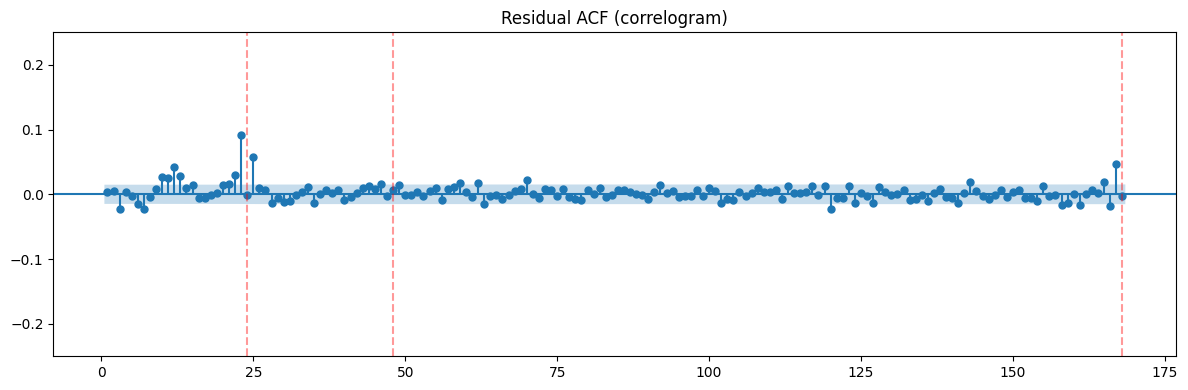

In [ ]:
# -------------------------------------------------
# Post-fit diagnostic: residual autocorrelation (correlogram)
# -------------------------------------------------
# If the chosen order is adequate, residuals should be white noise:
# no leftover autocorrelation at any lag, especially the seasonal lags 24 / 168.
from statsmodels.graphics.tsaplots import plot_acf

# drop the first 24 residuals (state-space initialization artifacts)
resid = sarimax_fit.resid[24:]

# correlogram
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(resid, lags=168, zero=False, ax=ax, title="Residual ACF (correlogram)")
for lag in (24, 48, 168):
    ax.axvline(lag, color="red", linestyle="--", alpha=0.4)
ax.set_ylim(-0.25, 0.25)
plt.tight_layout()
plt.show()

Residual diagnostics for the selected SARIMAX order are shown below.

### ARIMA

In [ ]:
import pmdarima as pm
from pmdarima.arima.utils import ndiffs

# -------------------------------------------------
# Hyperparameter tuning (stepwise AIC search via pmdarima)
# -------------------------------------------------
arima_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh-transformed target

d = ndiffs(arima_endog_train, test="kpss")

auto_model = pm.auto_arima(
    arima_endog_train,
    seasonal=False,            # ARIMA no SARIMA
    d=d,
    with_intercept=(d == 0),   # if d==1 intercept makes no sense, because no linear trend in price
    max_order=None,            # keine Beschränkung auf p+q <= 5
    stepwise=True,
    information_criterion="aic",
    maxiter=1000,
    method="nm",
    trace=True,
    suppress_warnings=False,
    error_action="trace",
)
print(auto_model.summary())
ARIMA_ORDER = auto_model.order
print("Best ARIMA order:", ARIMA_ORDER)
print("With intercept:", auto_model.with_intercept)

Performing stepwise search to minimize aic


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-29846.357, Time=15.89 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-21831.102, Time=0.25 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-27556.966, Time=0.57 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-27031.060, Time=0.68 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-27957.589, Time=3.11 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-29841.071, Time=2.45 sec


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(3,1,2)(0,0,0)[0]             : AIC=inf, Time=12.28 sec


...

 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-28105.292, Time=6.38 sec


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(3,1,3)(0,0,0)[0]             : AIC=-28378.064, Time=10.47 sec


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-28024.172, Time=12.25 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0]          
Total fit time: 80.793 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                17544
Model:               SARIMAX(2, 1, 2)   Log Likelihood               14928.178
Date:                Fri, 31 Jul 2026   AIC                         -29846.357
Time:                        14:51:33   BIC                         -29807.495
Sample:                    01-01-2023   HQIC                        -29833.561
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4596      0.008    188.965      0.000       1.

In [ ]:
# -------------------------------------------------
# Model with tuned order
# -------------------------------------------------
from statsmodels.tsa.arima.model import ARIMA

ARIMA_ORDER = (2, 1, 2)  # best order from auto_arima
INTERCEPT = "n"

arima_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh-transformed target
arima_endog_test  = test_df[TARGET_COL].astype(np.float64)

arima_fit = ARIMA(
    arima_endog_train,
    order=ARIMA_ORDER,
    trend=INTERCEPT,
).fit(method_kwargs={"maxiter": 1000, "method": "nm"})

/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
# save model
arima_fit.save("models/arima_fit.pkl")

### Transformer-BiLSTM

In [ ]:
# -------------------------------------------------
# Transformer-BiLSTM: shared builder, evaluation and search space
# Architecture following Khan et al. (IEEE TIA 2026), extended by the exogenous
# input branch used for the other sequential models in this study.
# -------------------------------------------------
class PositionalEmbedding(layers.Layer):
    """Adds a learned position vector to every step of the projected sequence."""

    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=self.seq_len, delta=1)
        return x + self.pos_emb(positions)


def build_tf_bilstm(params):
    d_model = int(params["d_model"])
    num_heads = int(params["num_heads"])
    ff_dim = 4 * d_model                      # standard transformer convention

    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_anchored.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_anchored.shape[1],))

    # The price sequence has a single channel, so it is projected to d_model first.
    x = layers.Dense(d_model)(input_seq)
    x = PositionalEmbedding(LOOKBACK, d_model)(x)

    # One transformer encoder block: attention -> residual -> feed forward -> residual
    attn = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads
    )(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(d_model)(ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ff)

    hidden = layers.Bidirectional(
        layers.LSTM(
            units=int(params["lstm_units"]),
            dropout=float(params["lstm_dropout"]),
            recurrent_dropout=float(params["recurrent_dropout"]),
        )
    )(x)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


def evaluate_tf_bilstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=50,
    patience=6,
):
    """Holdout evaluation with the last 15% of the training sequence."""
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_tf_bilstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


def run_tf_bilstm_search(label, X_seq, X_exog, y):
    """Random search over tf_bilstm_search_space for one input strategy."""
    print(f"Starte Transformer-BiLSTM Hyperparameter-Suche, {label} ({n_trials} Trials, Holdout 15%) ...")
    results = []
    for i, params in enumerate(tf_bilstm_search_space, start=1):
        print(f"[{i}/{n_trials}] {label} teste: {params}")
        scores = evaluate_tf_bilstm_params_on_dataset(
            params=params, X_seq=X_seq, X_exog=X_exog, y=y,
            val_frac=0.15, epochs=50, patience=6,
        )
        row = params.copy()
        row["val_mae_t"] = scores["mae_t"]
        row["val_rmse_t"] = scores["rmse_t"]
        row["epochs_ran"] = scores["epochs_ran"]
        results.append(row)
        print(
            f"    -> {label} Val-MAE_t: {row['val_mae_t']:.4f} | "
            f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
            f"Epochs: {row['epochs_ran']}"
        )
    return (
        pd.DataFrame(results)
        .sort_values(["val_mae_t", "val_rmse_t"])
        .reset_index(drop=True)
    )


# -------------------------------------------------
# Search space
# d_model must be divisible by num_heads; every combination below satisfies this.
# -------------------------------------------------
tf_bilstm_param_dist = {
    "d_model": [32, 64, 96, 128],
    "num_heads": [4, 8],
    "lstm_units": [32, 48, 64, 96],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.1, 0.2, 0.3],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 5e-4, 1e-3, 2e-3],
    "batch_size": [32, 64],
}

n_trials = 30
tf_bilstm_search_space = list(
    ParameterSampler(tf_bilstm_param_dist, n_iter=n_trials, random_state=1904)
)

In [ ]:
# -------------------------------------------------
# Transformer-BiLSTM: Day-Anchored Lookback Strategy
# -------------------------------------------------
tf_bilstm_anchored_results_df = run_tf_bilstm_search(
    "Day-Anchored Strategy",
    X_train_seq_anchored,
    X_train_exog_anchored,
    y_train_anchored,
)
display(tf_bilstm_anchored_results_df.head(5))

best_tf_bilstm_anchored_params = {
    k: tf_bilstm_anchored_results_df.loc[0, k] for k in tf_bilstm_param_dist.keys()
}
print("\nBeste Transformer-BiLSTM-Hyperparameter (Day-Anchored Lookback Strategy):")
for k, v in best_tf_bilstm_anchored_params.items():
    print(f"  {k}: {v}")

# ---------- Final fit ----------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

tf_bilstm_anchored = build_tf_bilstm(best_tf_bilstm_anchored_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = tf_bilstm_anchored.fit(
    [X_train_seq_anchored, X_train_exog_anchored],
    y_train_anchored,
    validation_split=0.15,
    epochs=50,
    batch_size=int(best_tf_bilstm_anchored_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

joblib.dump(tf_bilstm_anchored, "models/tf_bilstm_anchored.joblib")
print("Saved models/tf_bilstm_anchored.joblib")

Starte Transformer-BiLSTM Hyperparameter-Suche, Day-Anchored Strategy (30 Trials, Holdout 15%) ...
[1/30] Day-Anchored Strategy teste: {'recurrent_dropout': 0.0, 'num_heads': 8, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.3, 'd_model': 64, 'batch_size': 64}
    -> Day-Anchored Strategy Val-MAE_t: 0.1330 | Val-RMSE_t: 0.1924 | Epochs: 15
[2/30] Day-Anchored Strategy teste: {'recurrent_dropout': 0.0, 'num_heads': 8, 'lstm_units': 96, 'lstm_dropout': 0.0, 'learning_rate': 0.001, 'dense_units': 128, 'dense_dropout': 0.2, 'd_model': 32, 'batch_size': 32}
    -> Day-Anchored Strategy Val-MAE_t: 0.1356 | Val-RMSE_t: 0.1926 | Epochs: 18
[3/30] Day-Anchored Strategy teste: {'recurrent_dropout': 0.0, 'num_heads': 4, 'lstm_units': 48, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.3, 'd_model': 32, 'batch_size': 32}
    -> Day-Anchored Strategy Val-MAE_t: 0.1291 | Val-RMSE_t: 0.1847 | Epochs: 17
[4/30] Da

,recurrent_dropout,num_heads,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,d_model,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,4,48,0.2000,0.0010,64,0.3000,32,32,0.1291,0.1847,17
1,0.0000,4,64,0.1000,0.0005,128,0.1000,96,32,0.1296,0.1910,32
2,0.0000,4,64,0.1000,0.0020,32,0.3000,32,32,0.1301,0.1854,24
3,0.0000,4,96,0.0000,0.0010,32,0.3000,32,32,0.1306,0.1886,15
4,0.0000,4,64,0.2000,0.0020,32,0.2000,64,64,0.1307,0.1901,27



Beste Transformer-BiLSTM-Hyperparameter (Day-Anchored Lookback Strategy):
  d_model: 32
  num_heads: 4
  lstm_units: 48
  dense_units: 64
  lstm_dropout: 0.2
  dense_dropout: 0.3
  recurrent_dropout: 0.0
  learning_rate: 0.001
  batch_size: 32
Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - loss: 0.2380 - rmse: 0.3204 - val_loss: 0.1483 - val_rmse: 0.2034
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1829 - rmse: 0.2383 - val_loss: 0.1482 - val_rmse: 0.2038
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1647 - rmse: 0.2174 - val_loss: 0.1482 - val_rmse: 0.2060
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1565 - rmse: 0.2063 - val_loss: 0.1387 - val_rmse: 0.1962
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.1485 - rmse: 0.1984 - val_loss: 0.1405 - val_rmse: 0.1982
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.1417 - rmse: 0.1902 - val_loss: 0.1382 - val_rmse: 0.1948
Epoch 7/50
465/465 ━━━━━━━━━

In [ ]:
# -------------------------------------------------
# Transformer-BiLSTM: Recursive Rolling-Lookback Strategy
# -------------------------------------------------
tf_bilstm_rolling_results_df = run_tf_bilstm_search(
    "Recursive Rolling Strategy",
    X_train_seq_rolling,
    X_train_exog_rolling,
    y_train_rolling,
)
display(tf_bilstm_rolling_results_df.head(5))

best_tf_bilstm_rolling_params = {
    k: tf_bilstm_rolling_results_df.loc[0, k] for k in tf_bilstm_param_dist.keys()
}
print("\nBeste Transformer-BiLSTM-Hyperparameter (Recursive Rolling-Lookback Strategy):")
for k, v in best_tf_bilstm_rolling_params.items():
    print(f"  {k}: {v}")

# ---------- Final fit ----------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

tf_bilstm_rolling = build_tf_bilstm(best_tf_bilstm_rolling_params)

early_stop_rolling = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = tf_bilstm_rolling.fit(
    [X_train_seq_rolling, X_train_exog_rolling],
    y_train_rolling,
    validation_split=0.15,
    epochs=50,
    batch_size=int(best_tf_bilstm_rolling_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rolling],
    verbose=1,
)

joblib.dump(tf_bilstm_rolling, "models/tf_bilstm_rolling.joblib")
print("Saved models/tf_bilstm_rolling.joblib")

Starte Transformer-BiLSTM Hyperparameter-Suche, Recursive Rolling Strategy (30 Trials, Holdout 15%) ...
[1/30] Recursive Rolling Strategy teste: {'recurrent_dropout': 0.0, 'num_heads': 8, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.3, 'd_model': 64, 'batch_size': 64}
    -> Recursive Rolling Strategy Val-MAE_t: 0.0620 | Val-RMSE_t: 0.0981 | Epochs: 50
[2/30] Recursive Rolling Strategy teste: {'recurrent_dropout': 0.0, 'num_heads': 8, 'lstm_units': 96, 'lstm_dropout': 0.0, 'learning_rate': 0.001, 'dense_units': 128, 'dense_dropout': 0.2, 'd_model': 32, 'batch_size': 32}
    -> Recursive Rolling Strategy Val-MAE_t: 0.0723 | Val-RMSE_t: 0.1140 | Epochs: 34
[3/30] Recursive Rolling Strategy teste: {'recurrent_dropout': 0.0, 'num_heads': 4, 'lstm_units': 48, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.3, 'd_model': 32, 'batch_size': 32}
    -> Recursive Rolling Strategy Val-MAE_t: 0.0675 | Val-RM

,recurrent_dropout,num_heads,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,d_model,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,8,32,0.2000,0.0010,64,0.3000,64,64,0.0620,0.0981,50
1,0.0000,8,32,0.0000,0.0005,64,0.2000,32,64,0.0628,0.1035,50
2,0.0000,4,96,0.0000,0.0003,128,0.1000,128,64,0.0640,0.1022,43
3,0.0000,4,32,0.2000,0.0020,64,0.3000,32,64,0.0641,0.0989,50
4,0.0000,4,48,0.2000,0.0010,64,0.3000,32,32,0.0675,0.1064,32



Beste Transformer-BiLSTM-Hyperparameter (Recursive Rolling-Lookback Strategy):
  d_model: 64
  num_heads: 8
  lstm_units: 32
  dense_units: 64
  lstm_dropout: 0.2
  dense_dropout: 0.3
  recurrent_dropout: 0.0
  learning_rate: 0.001
  batch_size: 64
Epoch 1/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.2357 - rmse: 0.3276 - val_loss: 0.1247 - val_rmse: 0.1814
Epoch 2/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1569 - rmse: 0.2062 - val_loss: 0.1091 - val_rmse: 0.1683
Epoch 3/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1409 - rmse: 0.1839 - val_loss: 0.1002 - val_rmse: 0.1611
Epoch 4/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1290 - rmse: 0.1699 - val_loss: 0.0957 - val_rmse: 0.1530
Epoch 5/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1214 - rmse: 0.1613 - val_loss: 0.1017 - val_rmse: 0.1593
Epoch 6/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1171 - rmse: 0.1565 - val_loss: 0.0915 - val_rmse: 0.1467
Epoch 7/50
233/233 ━━━━

### SARIMAX-XGBoost residual hybrid

In [ ]:
# -------------------------------------------------
# SARIMAX-XGBoost residual hybrid (SARIMAX)
# -------------------------------------------------
RESID_BLOCK_MONTHS = 6                      # refit interval; the first block is the initial fit window
RESID_PATH = "data/sarimax_train_residuals.csv"

SARIMAX_ORDER = (1, 0, 1)
SARIMAX_SEASONAL = (1, 1, 1, 24)

sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

block_starts = pd.date_range(
    TRAIN_START, TRAIN_END, freq=f"{RESID_BLOCK_MONTHS}MS", tz=TRAIN_START.tz, inclusive="left"
)
resid_blocks = block_starts[1:]

if os.path.exists(RESID_PATH):
    resid_series = pd.read_csv(RESID_PATH, index_col=0).iloc[:, 0]
    # Local timestamps carry mixed UTC offsets across DST, so parse via UTC first.
    resid_series.index = pd.to_datetime(resid_series.index, utc=True).tz_convert(TRAIN_START.tz)
    resid_series = resid_series.astype(np.float64)
    done_blocks = {b for b in resid_blocks if (resid_series.index >= b).any()
                   and (resid_series.index < b + pd.DateOffset(months=RESID_BLOCK_MONTHS)).any()}
    print(f"Resuming: {len(done_blocks)}/{len(resid_blocks)} Bloecke bereits vorhanden.")
else:
    resid_series = pd.Series(dtype=np.float64)
    done_blocks = set()

for b_start in resid_blocks:
    if b_start in done_blocks:
        print(f"{b_start.date()} skipped (done)")
        continue
    b_end = min(b_start + pd.DateOffset(months=RESID_BLOCK_MONTHS), TRAIN_END)

    # Refit on everything strictly before this block.
    hist = sarimax_endog_train.loc[sarimax_endog_train.index < b_start]
    hist_exog = sarimax_exog_train.loc[sarimax_exog_train.index < b_start]
    fitted = SARIMAX(
        endog=hist, exog=hist_exog,
        order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL,
        trend="n",
    ).fit(disp=False, maxiter=300, method="lbfgs")
    rv = fitted.mle_retvals
    if not rv.get("converged"):
        print(f"  WARNING {b_start.date()}: not converged (warnflag={rv.get('warnflag')})")

    running = fitted
    block_preds = {}
    for day in pd.date_range(b_start, b_end - pd.Timedelta(hours=1), freq="D"):
        nxt = day + pd.DateOffset(days=1)
        mask = (sarimax_exog_train.index >= day) & (sarimax_exog_train.index < nxt)
        exog_day = sarimax_exog_train.loc[mask].sort_index().asfreq("h")
        if len(exog_day) == 0 or exog_day.isna().any().any():
            continue
        fc = running.get_forecast(steps=len(exog_day), exog=exog_day)
        for ts, val in fc.predicted_mean.items():
            block_preds[ts] = val
        actual_day = sarimax_endog_train.reindex(exog_day.index)
        if actual_day.isna().any():
            continue
        running = running.extend(endog=actual_day, exog=exog_day)

    pred = pd.Series(block_preds, dtype=np.float64).sort_index()
    resid_series = pd.concat([resid_series,
                              sarimax_endog_train.reindex(pred.index) - pred]).sort_index()
    resid_series.to_frame("resid").to_csv(RESID_PATH)
    print(f"{b_start.date()}  {len(pred)} Stunden  |  MAE_t={np.abs(resid_series).mean():.4f}")

resid_series = resid_series.sort_index().rename("resid")
print(f"\nResiduen: {len(resid_series)} Stunden von {resid_series.index.min()} bis {resid_series.index.max()}")
display(resid_series.describe().to_frame().T)

/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_47039/917210194.py:73: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  resid_series = pd.concat([resid_series,


2023-07-01  4417 Stunden  |  MAE_t=0.1252
2024-01-01  4367 Stunden  |  MAE_t=0.1212
2024-07-01  4417 Stunden  |  MAE_t=0.1250

Residuen: 13201 Stunden von 2023-07-01 00:00:00+02:00 bis 2024-12-31 23:00:00+01:00


,count,mean,std,min,25%,50%,75%,max
resid,"13,201.0000",0.0022,0.1729,-2.2723,-0.0832,0.0132,0.0983,1.2551


In [ ]:
# -------------------------------------------------
# SARIMAX-XGBoost residual hybrid (XGBoost)
# -------------------------------------------------
RESID_COL = "resid"

resid_series = pd.read_csv("data/sarimax_train_residuals.csv", index_col=0).iloc[:, 0]
# Local timestamps carry mixed UTC offsets across DST, so parse via UTC first.
resid_series.index = pd.to_datetime(resid_series.index, utc=True).tz_convert(TRAIN_START.tz)
resid_series = resid_series.astype(np.float64).sort_index().rename(RESID_COL)
print(f"Residuen: {len(resid_series)} Stunden von "
      f"{resid_series.index.min()} bis {resid_series.index.max()}")

resid_df = train_df.loc[resid_series.index].copy()
resid_df[RESID_COL] = resid_series

X_seq_res, X_exog_res, y_res, ts_res = build_anchored_dataset(
    resid_df, [RESID_COL], FEATURE_COLS, RESID_COL, LOOKBACK,
)
X_res = np.concatenate([X_seq_res.reshape(X_seq_res.shape[0], -1), X_exog_res], axis=1)
print(f"Residual training set: X={X_res.shape}  y={y_res.shape}")

xgb_common_params = dict(
    objective="reg:squarederror",
    random_state=1904,
    #n_jobs=-1,
    #device="cuda"
)

xgb_res_param_dist = {
    "n_estimators": [100, 200, 400, 500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "min_child_weight": [1, 3, 5, 7],
}

search_resid = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_common_params),
    param_distributions=xgb_res_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=TimeSeriesSplit(n_splits=5),
    random_state=1904,
    n_jobs=1,
    verbose=1,
)
search_resid.fit(X_res, y_res)

print(f"\nBest residual-model CV-MAE_t: {-search_resid.best_score_:.4f}")
print("Best params:")
for k, v in search_resid.best_params_.items():
    print(f"  {k}: {v}")

sarimax_xgb_resid = search_resid.best_estimator_
sarimax_xgb_resid.save_model("models/sarimax_xgb_resid.ubj")
print("Saved models/sarimax_xgb_resid.ubj")

Residual training set: X=(13153, 59)  y=(13153,)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best residual-model CV-MAE_t: 0.1233
Best params:
  subsample: 0.6
  reg_lambda: 2.0
  n_estimators: 100
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.03
  colsample_bytree: 0.6
Saved models/sarimax_xgb_resid.ubj


## Validation

In [ ]:
# ── Validation: load all models and evaluate them on the validation set ──
RESID_COL = "resid"


class PositionalEmbedding(layers.Layer):
    """Adds a learned position vector to every step of the projected sequence."""

    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=d_model)

    def call(self, x):
        positions = tf.range(start=0, limit=self.seq_len, delta=1)
        return x + self.pos_emb(positions)


def read_hourly(path):
    s = pd.read_csv(path, index_col=0).iloc[:, 0]
    # Local timestamps carry mixed UTC offsets across DST, so parse via UTC first.
    s.index = pd.to_datetime(s.index, utc=True).tz_convert(TRAIN_START.tz)
    return s.astype(np.float64).sort_index()


resid_series = read_hourly("data/sarimax_train_residuals.csv")

records = []

# ---------- Tabular models: XGBoost / RandomForest / SVM ----------
# Each has Base-Feature, Day-Anchored Lookback and Recursive Rolling-Lookback variants.
def load_tabular_model(name, strategy):
    if name == "xgb":
        model = XGBRegressor()
        model.load_model(f"models/{name}_{strategy}.ubj")
        return model
    return joblib.load(f"models/{name}_{strategy}.joblib")


for name in ["xgb", "rf", "svm"]:
    base = load_tabular_model(name, "base")
    anchored = load_tabular_model(name, "anchored")
    rolling = load_tabular_model(name, "rolling")

    y_base    = asinh_inverse(to_numpy_float32(base.predict(X_val_base)), c)
    y_anchored = asinh_inverse(to_numpy_float32(anchored.predict(X_val_flat_anchored)), c)
    y_rolling  = asinh_inverse(
        rolling_predict_tabular(
            rolling, rolling_df_val, val_rolling_index, FEATURE_COLS, TARGET_COL, LOOKBACK
        ),
        c,
    )

    records += [
        {"model": f"{name}_base",     "mae": mae_score(y_val, y_base),            "rmse": rmse_score(y_val, y_base)},
        {"model": f"{name}_anchored", "mae": mae_score(y_val, y_anchored),        "rmse": rmse_score(y_val, y_anchored)},
        {"model": f"{name}_rolling",  "mae": mae_score(y_val_rolling, y_rolling), "rmse": rmse_score(y_val_rolling, y_rolling)},
    ]

# ---------- Sequence models: LSTM / BiLSTM ----------
for name in ["lstm", "bilstm"]:
    anchored = joblib.load(f"models/{name}_anchored.joblib")
    rolling = joblib.load(f"models/{name}_rolling.joblib")

    y_anchored = asinh_inverse(
        to_numpy_float32(anchored.predict([X_val_seq_anchored, X_val_exog_anchored], verbose=0)),
        c,
    )
    y_rolling = asinh_inverse(
        rolling_predict_keras(
            rolling, rolling_df_val, val_rolling_index, FEATURE_COLS, TARGET_COL, LOOKBACK
        ),
        c,
    )

    records += [
        {"model": f"{name}_anchored", "mae": mae_score(y_val, y_anchored),        "rmse": rmse_score(y_val, y_anchored)},
        {"model": f"{name}_rolling",  "mae": mae_score(y_val_rolling, y_rolling), "rmse": rmse_score(y_val_rolling, y_rolling)},
    ]

# ---------- Transformer-BiLSTM ----------
# PositionalEmbedding is a custom layer, so it must be supplied when deserialising.
with tf.keras.utils.custom_object_scope({"PositionalEmbedding": PositionalEmbedding}):
    tf_bilstm_anchored = joblib.load("models/tf_bilstm_anchored.joblib")
    tf_bilstm_rolling = joblib.load("models/tf_bilstm_rolling.joblib")

y_tf_anchored = asinh_inverse(
    to_numpy_float32(
        tf_bilstm_anchored.predict([X_val_seq_anchored, X_val_exog_anchored], verbose=0)
    ),
    c,
)
y_tf_rolling = asinh_inverse(
    rolling_predict_keras(
        tf_bilstm_rolling, rolling_df_val, val_rolling_index, FEATURE_COLS, TARGET_COL, LOOKBACK
    ),
    c,
)

records += [
    {"model": "tf_bilstm_anchored", "mae": mae_score(y_val, y_tf_anchored),        "rmse": rmse_score(y_val, y_tf_anchored)},
    {"model": "tf_bilstm_rolling",  "mae": mae_score(y_val_rolling, y_tf_rolling), "rmse": rmse_score(y_val_rolling, y_tf_rolling)},
]

# ---------- SARIMAX (day-by-day multi-step forecast) ----------
sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train  = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

params = np.load("models/sarimax_params.npy")
spec = SARIMAX(
    endog=sarimax_endog_train, exog=sarimax_exog_train,
    order=(1, 0, 1), seasonal_order=(1, 1, 1, 24), trend="n",
)
sarimax_model = spec.smooth(params)

sarimax_endog_val = val_df[TARGET_COL].astype(np.float64)
sarimax_exog_val  = val_df[FEATURE_COLS].astype(np.float64)

# Forecast one local delivery day at a time. DST days can have 23 or 25 hours.
val_dates = pd.date_range(
    start=VAL_START.normalize(),
    end=VAL_END.normalize() - pd.DateOffset(days=1),
    freq="D",
)

sarimax_preds_t = {}
running_res = sarimax_model  # starts from the end of the training data
for day in val_dates:
    next_day = day + pd.DateOffset(days=1)
    day_mask = (sarimax_exog_val.index >= day) & (sarimax_exog_val.index < next_day)
    exog_day = sarimax_exog_val.loc[day_mask].sort_index().asfreq("h")

    if len(exog_day) == 0 or exog_day.isna().any().any():
        print(f"WARNING: {day.date()} skipped (missing exog).")
        continue

    forecast = running_res.get_forecast(steps=len(exog_day), exog=exog_day)
    for ts, val in forecast.predicted_mean.items():
        sarimax_preds_t[ts] = val

    actual_day = sarimax_endog_val.reindex(exog_day.index)
    if actual_day.isna().any():
        print(f"WARNING: {day.date()} state not updated (missing actuals).")
        continue
    running_res = running_res.extend(endog=actual_day, exog=exog_day)

sarimax_t = pd.Series(sarimax_preds_t, dtype=np.float64).sort_index().reindex(val_df.index)
if sarimax_t.isna().any():
    raise ValueError(f"SARIMAX forecast is missing {int(sarimax_t.isna().sum())} validation timestamps.")

y_pred_sarimax = asinh_inverse(sarimax_t, c)
records.append(
    {"model": "sarimax",
     "mae":  mae_score(y_val, y_pred_sarimax.to_numpy()),
     "rmse": rmse_score(y_val, y_pred_sarimax.to_numpy())}
)

# ---------- Naive 24h baseline ----------
y_pred_naive24 = data.loc[val_df.index, "price_lag_24h"].to_numpy(dtype=np.float32)
if np.isnan(y_pred_naive24).any():
    raise ValueError("naive 24h baseline contains NaNs in the validation window.")
records.append(
    {"model": "naive_24h",
     "mae":  mae_score(y_val, y_pred_naive24),
     "rmse": rmse_score(y_val, y_pred_naive24)}
)

# ---------- SARIMAX-XGBoost residual hybrid ----------

xgb_resid = XGBRegressor()
xgb_resid.load_model("models/sarimax_xgb_resid.ubj")

# Residuals known at gate closure: the training blocks plus the validation days
# already forecast.
val_resid = val_df[TARGET_COL] - sarimax_t
resid_known = pd.concat([resid_series, val_resid]).sort_index()

resid_val_frame = val_with_history_df.copy()
resid_val_frame[RESID_COL] = resid_known.reindex(resid_val_frame.index)

seq_r, exog_r, _, ts_r = build_anchored_dataset(
    resid_val_frame, [RESID_COL], FEATURE_COLS, RESID_COL, LOOKBACK,
)
X_val_resid = np.concatenate([seq_r.reshape(seq_r.shape[0], -1), exog_r], axis=1)

n_hat = to_numpy_float32(xgb_resid.predict(X_val_resid))
y_pred_hybrid = asinh_inverse(sarimax_t.reindex(ts_r).to_numpy() + n_hat, c)
y_true_hybrid = data.loc[ts_r, TARGET_COL].to_numpy(dtype=np.float32)

records.append({
    "model": "sarimax_xgb_resid",
    "mae": mae_score(y_true_hybrid, y_pred_hybrid),
    "rmse": rmse_score(y_true_hybrid, y_pred_hybrid),
})

# ---------- ARIMA (day-by-day multi-step forecast) ----------
arima_model = ARIMAResults.load("models/arima_fit.pkl")
arima_endog_val = val_df[TARGET_COL].astype(np.float64).asfreq("h")

arima_preds_t = {}
running_res = arima_model  # starts from the end of the training data
for day in val_dates:                      # val_dates is already defined in the SARIMAX block above
    next_day = day + pd.DateOffset(days=1)
    mask = (arima_endog_val.index >= day) & (arima_endog_val.index < next_day)
    day_idx = arima_endog_val.loc[mask].sort_index().asfreq("h").index
    if len(day_idx) == 0:
        continue
    forecast = running_res.get_forecast(steps=len(day_idx))
    for ts, val in zip(day_idx, forecast.predicted_mean):
        arima_preds_t[ts] = val
    actual_day = arima_endog_val.reindex(day_idx)
    if actual_day.isna().any():
        continue
    running_res = running_res.extend(endog=actual_day)

arima_t = pd.Series(arima_preds_t, dtype=np.float64).sort_index().reindex(val_df.index)
if arima_t.isna().any():
    raise ValueError(f"ARIMA forecast is missing {int(arima_t.isna().sum())} validation timestamps.")
y_pred_arima = asinh_inverse(arima_t, c)

records.append(
    {"model": "arima",
     "mae":  mae_score(y_val, y_pred_arima.to_numpy()),
     "rmse": rmse_score(y_val, y_pred_arima.to_numpy())}
)

# ---------- Combined score table ----------
scores = pd.DataFrame(records).sort_values("mae", ignore_index=True)
display(scores)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'positional_embedding', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


,model,mae,rmse
0,sarimax_xgb_resid,15.1984,23.0024
1,sarimax,15.9998,24.0307
2,xgb_anchored,16.8321,26.0837
3,rf_anchored,17.2500,27.0209
4,xgb_base,17.4689,26.6587
5,lstm_anchored,17.6224,27.3343
6,rf_base,17.6902,26.8617
7,bilstm_anchored,17.7601,27.1335
8,svm_base,17.8230,27.1825
9,svm_anchored,17.9981,27.1422


The SARIMAX-XGBoost hybrid has the lowest validation MAE and RMSE. Stage 1 retains the lowest-MAE model from each class for Stage 2:
* SARIMAX,
* XGBoost with the day-anchored lookback strategy,
* LSTM with the day-anchored lookback strategy, and
* SARIMAX-XGBoost.

## Second Training

In [9]:
# --- Shared Stage-2 preprocessing for the second training (train+val) ---
# Val already served for model pre selection -> reuse its data for training here.
# Refit c and scaler on RAW train+val
trainval_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < VAL_END)].copy()

# c on the raw train+val price
c_tv = np.median(np.abs(trainval_df[TARGET_COL]))

# asinh with the new c (target + price lags)
for col in [TARGET_COL] + LAG_COLS:
    trainval_df[col] = asinh_transform(trainval_df[col], c_tv)

# refit the scaler on train+val
scaler_tv = RobustScaler()
trainval_df[SCALE_COLS] = scaler_tv.fit_transform(trainval_df[SCALE_COLS])

### XGBoost

In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
xgb_common_params = dict(
    objective="reg:squarederror",
    random_state=1904,
    n_jobs=-1,
    device="cuda"
)

param_dist = {
    "n_estimators": [400, 500, 600, 700],
    "learning_rate": [0.001, 0.005, 0.01, 0.02, 0.03],
    "max_depth": [5, 6, 8, 9],
    "subsample": [0.4, 0.5, 0.6, 0.7, 0.8],
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7, 0.8],
    "reg_lambda": [0.0, 0.1, 0.25, 0.5, 1.0, 2.0],
    "min_child_weight": [1, 3, 5, 7],
}

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# -------------------------------------------------
# Second training: tune lookback AND hyperparameters (CV on train+val)
# -------------------------------------------------

LOOKBACK_CANDIDATES = [12, 18, 24, 48, 72, 96, 120, 168]
max_L = max(LOOKBACK_CANDIDATES)
common_start = TRAIN_START + pd.Timedelta(hours=max_L)  # shared target set across all lookbacks

# trainval_df / c_tv / scaler_tv come from the shared Stage-2 cell above


def build_anchored_flat_train(L):
    seq, exog, y, ts = build_anchored_dataset(trainval_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, L)
    m = ts >= common_start                              # align so every L predicts the same targets
    seq, exog, y = seq[m], exog[m], y[m]
    return np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1), y


# For each lookback, hyperparameter search
results_lb = []
best_params_by_L = {}
for L in LOOKBACK_CANDIDATES:
    X_L, y_L = build_anchored_flat_train(L)
    search = RandomizedSearchCV(
        estimator=XGBRegressor(**xgb_common_params),
        param_distributions=param_dist,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=1904,
        n_jobs=1,
        verbose=0,
    )
    search.fit(X_L, y_L)
    cv_mae = -search.best_score_
    best_params_by_L[L] = search.best_params_
    results_lb.append({"lookback": L, "cv_mae": cv_mae, **search.best_params_})
    print(f"Lookback {L:3d} -> CV-MAE={cv_mae:.4f}  best_params={search.best_params_}")

lb_df = pd.DataFrame(results_lb).sort_values("cv_mae", ignore_index=True)
print("\n", lb_df, sep="")

XGB_LOOKBACK = int(lb_df.loc[0, "lookback"])
best_params_lb = best_params_by_L[XGB_LOOKBACK]
print(f"\nBest lookback: {XGB_LOOKBACK}  best_params={best_params_lb}")

# retrain the final model with the best (lookback, params) on the full train+val, then save
seq, exog, y_best, _ = build_anchored_dataset(trainval_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, XGB_LOOKBACK)
X_best = np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1)
xgb_anchored_final = XGBRegressor(**xgb_common_params, **best_params_lb).fit(X_best, y_best)
xgb_anchored_final.save_model("models/xgb_anchored_final.ubj")
print("Saved models/xgb_anchored_final.ubj")


Lookback  12 -> CV-MAE=0.1298  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  18 -> CV-MAE=0.1283  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  24 -> CV-MAE=0.1281  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  48 -> CV-MAE=0.1290  best_params={'subsample': 0.4, 'reg_lambda': 0.25, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.02, 'colsample_bytree': 0.6}
Lookback  72 -> CV-MAE=0.1303  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  96 -> CV-MAE=0.1301  best_params={'subsample

### LSTM

In [ ]:
# -------------------------------------------------
# Second training: tune lookback + hyperparameters for LSTM
# -------------------------------------------------
LOOKBACK_CANDIDATES = [12, 18, 24, 48, 72, 96, 120, 168]
max_L = max(LOOKBACK_CANDIDATES)
common_start = TRAIN_START + pd.Timedelta(hours=max_L)   # shared target set for a fair comparison
N_TRIALS = 30

lstm_param_dist = {
    "lstm_units": [64, 96, 128, 160, 196],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [16, 32, 64],
}


# uses trainval_df (train+val, already asinh/scaled with c_tv / scaler_tv)

def build_lstm_dyn(params, seq_len, n_channels, n_exog):
    input_seq  = layers.Input(shape=(seq_len, n_channels))
    input_exog = layers.Input(shape=(n_exog,))
    hidden = layers.LSTM(
        units=int(params["lstm_units"]),
        dropout=float(params["lstm_dropout"]),
        recurrent_dropout=float(params["recurrent_dropout"]),
    )(input_seq)
    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)
    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

def build_anchored_trainval(L, align=True):
    seq, exog, y, ts = build_anchored_dataset(trainval_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, L)
    if align:
        m = ts >= common_start                          # same targets across all L
        seq, exog, y = seq[m], exog[m], y[m]
    return seq, exog, y

def eval_lstm_params(params, X_seq, X_exog, y, val_frac=0.2, epochs=40, patience=6):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)
    n = len(y); n_val = int(n * val_frac)
    tr, va = np.arange(0, n - n_val), np.arange(n - n_val, n)
    model = build_lstm_dyn(params, X_seq.shape[1], X_seq.shape[2], X_exog.shape[1])
    es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    hist = model.fit(
        [X_seq[tr], X_exog[tr]], y[tr],
        validation_data=([X_seq[va], X_exog[va]], y[va]),
        epochs=epochs, batch_size=int(params["batch_size"]),
        shuffle=False, callbacks=[es], verbose=0,
    )
    val_mae = float(min(hist.history["val_loss"]))       # best-epoch val MAE (asinh scale)
    del model; gc.collect()
    return val_mae

# --- outer loop over lookback, inner random search per lookback (with resume) ---
LSTM_LB_RESULTS = "data/lstm_anchored_tuning.csv"

if os.path.exists(LSTM_LB_RESULTS):
    results_lb = pd.read_csv(LSTM_LB_RESULTS).to_dict("records")
    done_L = {int(r["lookback"]) for r in results_lb}
    print(f"Resuming: lookbacks done = {sorted(done_L)}")
else:
    results_lb = []
    done_L = set()

for L in LOOKBACK_CANDIDATES:
    if L in done_L:
        print(f"Lookback {L:3d} skipped (already done)")
        continue
    X_seq, X_exog, y = build_anchored_trainval(L, align=True)
    space = list(ParameterSampler(lstm_param_dist, n_iter=N_TRIALS, random_state=1904))
    scored = [(eval_lstm_params(p, X_seq, X_exog, y), p) for p in space]
    best_mae, best_params = min(scored, key=lambda t: t[0])
    results_lb.append({"lookback": L, "val_mae": best_mae, **best_params})
    pd.DataFrame(results_lb).to_csv(LSTM_LB_RESULTS, index=False)   # checkpoint after each lookback
    print(f"Lookback {L:3d} -> best Val-MAE={best_mae:.4f}  params={best_params}")

lb_df = pd.DataFrame(results_lb).sort_values("val_mae", ignore_index=True)
print("\n", lb_df, sep="")
LSTM_LOOKBACK = int(lb_df.loc[0, "lookback"])
best_params_lstm = {k: lb_df.loc[0, k] for k in lstm_param_dist.keys()}
print(f"\nBest lookback: {LSTM_LOOKBACK}  params={best_params_lstm}")

# --- final fit on FULL train+val (no alignment trim) with best (lookback, params) ---
X_seq, X_exog, y = build_anchored_trainval(LSTM_LOOKBACK, align=False)
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)
lstm_anchored_final = build_lstm_dyn(best_params_lstm, X_seq.shape[1], X_seq.shape[2], X_exog.shape[1])
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
lstm_anchored_final.fit(
    [X_seq, X_exog], y,
    validation_split=0.2,
    epochs=40, batch_size=int(best_params_lstm["batch_size"]),
    shuffle=False, callbacks=[es], verbose=1,
)
joblib.dump(lstm_anchored_final, "models/lstm_anchored_final.joblib")
print("Saved models/lstm_anchored_final.joblib")

Resuming: lookbacks done = [12, 18, 24, 48, 72, 96, 120, 168]
Lookback  24 skipped (already done)
Lookback  48 skipped (already done)
Lookback  72 skipped (already done)
Lookback  96 skipped (already done)
Lookback 120 skipped (already done)
Lookback 168 skipped (already done)

   Unnamed: 0  lookback  val_mae  recurrent_dropout  lstm_units  lstm_dropout  \
0         NaN        96   0.1375             0.0000         196        0.2000   
1      6.0000        12   0.1394             0.0000          64        0.0000   
2         NaN        48   0.1402             0.0000         128        0.0000   
3         NaN       168   0.1404             0.0000         196        0.2000   
4         NaN        72   0.1405             0.0000         196        0.2000   
5         NaN       120   0.1422             0.0000          96        0.1000   
6      7.0000        18   0.1424             0.0000         196        0.2000   
7         NaN        24   0.1431             0.0000         196        0.

### SARIMAX

In [ ]:
# -------------------------------------------------
# SARIMAX order selection on TRAIN+VAL (final-model order)
# restricted to the top-5 orders from the train-only tuning (no full grid re-run)
# -------------------------------------------------

sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh (c_tv)
sarimax_exog_tv  = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")  # scaled (scaler_tv)

# top-5 candidate orders from the train stage (avoid re-running the whole grid)
top5 = (pd.read_csv("data/sarimax_gridsearch_results.csv").sort_values("aic").head(5)[["p", "q", "P", "Q"]].astype(int))

RESULTS_PATH = "data/sarimax_gridsearch_trainval_top5.csv"   # new file (top-5 only, with convergence cols)

# Resume: load already computed results
if os.path.exists(RESULTS_PATH):
    candidates = pd.read_csv(RESULTS_PATH).to_dict("records")
    done_keys = {(int(r["p"]), int(r["q"]), int(r["P"]), int(r["Q"])) for r in candidates}
    print(f"Resuming: {len(done_keys)}/{len(top5)} candidates already done.")
else:
    candidates = []
    done_keys = set()

for p, q, P, Q in top5.itertuples(index=False):
    p, q, P, Q = int(p), int(q), int(P), int(Q)
    tag = f"({p},0,{q})({P},1,{Q},24)"
    if (p, q, P, Q) in done_keys:
        print(f"{tag}  skipped (done)")
        continue
    try:
        # capture warnings (do not suppress) so they can be shown per candidate
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            m = SARIMAX(
                endog=sarimax_endog_tv,
                exog=sarimax_exog_tv,
                order=(p, d, q),
                seasonal_order=(P, D, Q, S),
                trend="n",
            ).fit(disp=False, maxiter=300, method="lbfgs")

        rv = m.mle_retvals
        warn_names = sorted({w.category.__name__ for w in caught})
        candidates.append({
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": m.aic, "bic": m.bic,
            "converged": rv.get("converged"),
            "warnflag":  rv.get("warnflag"),
            "warnings":  "; ".join(warn_names),
        })
        done_keys.add((p, q, P, Q))
        pd.DataFrame(candidates).to_csv(RESULTS_PATH, index=False)     # save after each fit
        print(f"{tag}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
              f"converged={rv.get('converged')}  warnflag={rv.get('warnflag')}")
        for w in caught:
            print(f"        \u26a0 {w.category.__name__}: {str(w.message).splitlines()[0]}")
    except Exception as e:
        print(f"{tag}  FAILED: {e}")

tuning_tv_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
print("\nTop candidates (train+val), sorted by AIC:")
print(tuning_tv_df)

Resuming: 2/5 candidates already done.
(1,0,1)(1,1,1,24)  skipped (done)
(1,0,1)(0,1,1,24)  skipped (done)
(2,0,0)(0,1,1,24)  AIC=-46112.6  BIC=-45992.8  converged=True  warnflag=0
(1,0,0)(1,1,1,24)  AIC=-45307.5  BIC=-45187.6  converged=True  warnflag=0
(1,0,0)(0,1,1,24)  AIC=-45203.6  BIC=-45091.7  converged=True  warnflag=0

Top candidates (train+val), sorted by AIC:
   p  q  P  Q          aic          bic  converged  warnflag warnings
0  1  1  1  1 -46,256.3671 -46,128.4863       True         0      NaN
1  1  1  0  1 -46,183.5299 -46,063.6416       True         0      NaN
2  2  0  0  1 -46,112.6429 -45,992.7547       True         0         
3  1  0  1  1 -45,307.5029 -45,187.6146       True         0         
4  1  0  0  1 -45,203.5992 -45,091.7035       True         0         


In [ ]:
# -------------------------------------------------
# Model with tuned order
# -------------------------------------------------

sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh (c_tv)
sarimax_exog_tv  = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")  # scaled (scaler_tv)

SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL = (1, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1
    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")

sarimax_spec_final = SARIMAX(
    endog=sarimax_endog_tv,
    exog=sarimax_exog_tv,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    trend="n",
)
sarimax_fit_final = sarimax_spec_final.fit(disp=True, maxiter=300, method="lbfgs", callback=sarimax_callback)
print(sarimax_fit_final.summary())

# save model
np.save("models/sarimax_final_params.npy", np.asarray(sarimax_fit_final.params, dtype=np.float64))

SARIMAX iteration 1
SARIMAX iteration 5
SARIMAX iteration 10
SARIMAX iteration 15
SARIMAX iteration 20
SARIMAX iteration 25
SARIMAX iteration 30
SARIMAX iteration 35
SARIMAX iteration 40
SARIMAX iteration 45
SARIMAX iteration 50
SARIMAX iteration 55
SARIMAX iteration 60
SARIMAX iteration 65
SARIMAX iteration 70
SARIMAX iteration 75
SARIMAX iteration 80
SARIMAX iteration 85
SARIMAX iteration 90
SARIMAX iteration 95
SARIMAX iteration 100
SARIMAX iteration 105
SARIMAX iteration 110
SARIMAX iteration 115
SARIMAX iteration 120
SARIMAX iteration 125
SARIMAX iteration 130
SARIMAX iteration 135
SARIMAX iteration 140
SARIMAX iteration 145
SARIMAX iteration 150
SARIMAX iteration 155
SARIMAX iteration 160
SARIMAX iteration 165
SARIMAX iteration 170
SARIMAX iteration 175
SARIMAX iteration 180
SARIMAX iteration 185
SARIMAX iteration 190
SARIMAX iteration 195
                                     SARIMAX Results                                      
Dep. Variable:                           da_price  

OSError: [Errno 28] No space left on device

### SARIMAX-XGBoost residual hybrid

In [ ]:
# -------------------------------------------------
# SARIMAX-XGBoost residual hybrid
# -------------------------------------------------
RESID_TV_PATH = "data/sarimax_trainval_residuals.csv"

sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_tv = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")

block_starts_tv = pd.date_range(
    TRAIN_START, VAL_END, freq=f"{RESID_BLOCK_MONTHS}MS", tz=TRAIN_START.tz, inclusive="left"
)
resid_blocks_tv = block_starts_tv[1:]

if os.path.exists(RESID_TV_PATH):
    resid_series_tv = pd.read_csv(RESID_TV_PATH, index_col=0).iloc[:, 0]
    # Local timestamps carry mixed UTC offsets across DST, so parse via UTC first.
    resid_series_tv.index = pd.to_datetime(resid_series_tv.index, utc=True).tz_convert(TRAIN_START.tz)
    resid_series_tv = resid_series_tv.astype(np.float64)
    done_blocks_tv = {b for b in resid_blocks_tv if (resid_series_tv.index >= b).any()
                      and (resid_series_tv.index < b + pd.DateOffset(months=RESID_BLOCK_MONTHS)).any()}
    print(f"Resuming: {len(done_blocks_tv)}/{len(resid_blocks_tv)} Bloecke bereits vorhanden.")
else:
    resid_series_tv = pd.Series(dtype=np.float64)
    done_blocks_tv = set()

for b_start in resid_blocks_tv:
    if b_start in done_blocks_tv:
        print(f"{b_start.date()} skipped (done)")
        continue
    b_end = min(b_start + pd.DateOffset(months=RESID_BLOCK_MONTHS), VAL_END)

    # Refit on everything strictly before this block.
    hist = sarimax_endog_tv.loc[sarimax_endog_tv.index < b_start]
    hist_exog = sarimax_exog_tv.loc[sarimax_exog_tv.index < b_start]
    fitted = SARIMAX(
        endog=hist, exog=hist_exog,
        order=SARIMAX_ORDER, seasonal_order=SARIMAX_SEASONAL, trend="n",
    ).fit(disp=False, maxiter=1000, method="lbfgs")
    rv = fitted.mle_retvals
    if not rv.get("converged"):
        print(f"  WARNING {b_start.date()}: not converged (warnflag={rv.get('warnflag')})")

    running = fitted
    block_preds = {}
    for day in pd.date_range(b_start, b_end - pd.Timedelta(hours=1), freq="D"):
        nxt = day + pd.DateOffset(days=1)
        mask = (sarimax_exog_tv.index >= day) & (sarimax_exog_tv.index < nxt)
        exog_day = sarimax_exog_tv.loc[mask].sort_index().asfreq("h")
        if len(exog_day) == 0 or exog_day.isna().any().any():
            continue
        fc = running.get_forecast(steps=len(exog_day), exog=exog_day)
        for ts, val in fc.predicted_mean.items():
            block_preds[ts] = val
        actual_day = sarimax_endog_tv.reindex(exog_day.index)
        if actual_day.isna().any():
            continue
        running = running.extend(endog=actual_day, exog=exog_day)

    pred = pd.Series(block_preds, dtype=np.float64).sort_index()
    resid_series_tv = pd.concat([resid_series_tv,
                                 sarimax_endog_tv.reindex(pred.index) - pred]).sort_index()
    resid_series_tv.to_frame("resid").to_csv(RESID_TV_PATH)
    print(f"{b_start.date()}  {len(pred)} Stunden  |  MAE_t={np.abs(resid_series_tv).mean():.4f}")

resid_series_tv = resid_series_tv.sort_index().rename("resid")
print(f"\nResiduen: {len(resid_series_tv)} Stunden von {resid_series_tv.index.min()} bis {resid_series_tv.index.max()}")
display(resid_series_tv.describe().to_frame().T)

Resuming: 1/4 Bloecke bereits vorhanden.
2023-07-01 skipped (done)
2024-01-01  4367 Stunden  |  MAE_t=0.1199
2024-07-01  4417 Stunden  |  MAE_t=0.1237
2025-01-01  4343 Stunden  |  MAE_t=0.1244

Residuen: 17544 Stunden von 2023-07-01 00:00:00+02:00 bis 2025-06-30 23:00:00+02:00


,count,mean,std,min,25%,50%,75%,max
resid,"17,544.0000",-0.0018,0.1748,-2.2577,-0.0841,0.0099,0.0941,1.2564


In [ ]:
# -------------------------------------------------
# SARIMAX-XGBoost residual hybrid, stage 2: retune the residual model
# As for the other stage-2 models, the window length is tuned jointly with the
# hyperparameters. The window holds past SARIMAX residuals and ends before the
# delivery day starts.
# Standalone: needs the setup cells and data/sarimax_trainval_residuals.csv.
# -------------------------------------------------
RESID_COL = "resid"
RESID_LB_RESULTS = "data/sarimax_xgb_resid_tuning.csv"
RESID_MODEL_PATH = "models/sarimax_xgb_resid_final.ubj"

# Stage-2 preprocessing, refit on raw train+val (deterministic, no model fitting).
trainval_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < VAL_END)].copy()
c_tv = np.median(np.abs(trainval_df[TARGET_COL]))
for col in [TARGET_COL] + LAG_COLS:
    trainval_df[col] = asinh_transform(trainval_df[col], c_tv)
scaler_tv = RobustScaler()
trainval_df[SCALE_COLS] = scaler_tv.fit_transform(trainval_df[SCALE_COLS])

resid_series_tv = pd.read_csv("data/sarimax_trainval_residuals.csv", index_col=0).iloc[:, 0]
# Local timestamps carry mixed UTC offsets across DST, so parse via UTC first.
resid_series_tv.index = pd.to_datetime(resid_series_tv.index, utc=True).tz_convert(TRAIN_START.tz)
resid_series_tv = resid_series_tv.astype(np.float64).sort_index().rename(RESID_COL)
print(f"Residuen: {len(resid_series_tv)} Stunden von "
      f"{resid_series_tv.index.min()} bis {resid_series_tv.index.max()}")

# Tuning settings. The residual model keeps its own search space, as in stage 1.
xgb_common_params = dict(
    objective="reg:squarederror",
    random_state=1904,
    #n_jobs=-1,
    #device="cuda"
)

param_dist_resid = {
    "n_estimators": [400, 500, 600, 700],
    "learning_rate": [0.001, 0.005, 0.01, 0.02, 0.03],
    "max_depth": [6, 8, 9, 10],
    "subsample": [0.4, 0.5, 0.6, 0.7, 0.8],
    "colsample_bytree": [0.2, 0.3, 0.4, 0.5, 0.6],
    "reg_lambda": [0.0, 0.1, 0.25, 0.5, 1.0, 2.0],
    "min_child_weight": [1, 3, 5, 7],
}

tscv = TimeSeriesSplit(n_splits=5)

RESID_LOOKBACK_CANDIDATES = [6, 8, 12, 18, 24, 48, 72]
max_L_res = max(RESID_LOOKBACK_CANDIDATES)
common_start_res = resid_series_tv.index.min() + pd.Timedelta(hours=max_L_res)

resid_tv_df = trainval_df.loc[resid_series_tv.index].copy()
resid_tv_df[RESID_COL] = resid_series_tv


def build_resid_train(L):
    seq, exog, y, ts = build_anchored_dataset(
        resid_tv_df, [RESID_COL], FEATURE_COLS, RESID_COL, L,
    )
    keep = ts >= common_start_res                 # same targets across all L
    seq, exog, y = seq[keep], exog[keep], y[keep]
    return np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1), y


# Resume: reload the lookbacks that are already done.
if os.path.exists(RESID_LB_RESULTS):
    results_res = pd.read_csv(RESID_LB_RESULTS).to_dict("records")
    done_L = {int(r["lookback"]) for r in results_res}
    print(f"Resuming: lookbacks done = {sorted(done_L)}")
else:
    results_res, done_L = [], set()

for L in RESID_LOOKBACK_CANDIDATES:
    if L in done_L:
        print(f"Lookback {L:3d} skipped (already done)")
        continue
    X_L, y_L = build_resid_train(L)
    search = RandomizedSearchCV(
        estimator=XGBRegressor(**xgb_common_params),
        param_distributions=param_dist_resid,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=1904,
        n_jobs=1,
        verbose=0,
    )
    search.fit(X_L, y_L)
    cv_mae = -search.best_score_
    results_res.append({"lookback": L, "cv_mae": cv_mae, **search.best_params_})
    pd.DataFrame(results_res).to_csv(RESID_LB_RESULTS, index=False)   # checkpoint after each lookback
    print(f"Residual lookback {L:3d} -> CV-MAE_t={cv_mae:.4f}  best_params={search.best_params_}")

lb_df_res = pd.DataFrame(results_res).sort_values("cv_mae", ignore_index=True)
print("\n", lb_df_res, sep="")

RESID_LOOKBACK = int(lb_df_res.loc[0, "lookback"])
# After a resume the values come back from CSV as numpy types, so cast them.
INT_PARAMS = {"n_estimators", "max_depth", "min_child_weight"}
best_params_res = {
    k: int(lb_df_res.loc[0, k]) if k in INT_PARAMS else float(lb_df_res.loc[0, k])
    for k in param_dist_resid
}
print(f"\nBest residual lookback: {RESID_LOOKBACK}  best_params={best_params_res}")

# Final fit on the full residual sample (no alignment trim).
seq, exog, y_best, _ = build_anchored_dataset(
    resid_tv_df, [RESID_COL], FEATURE_COLS, RESID_COL, RESID_LOOKBACK,
)
X_best = np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1)
sarimax_xgb_resid_final = XGBRegressor(**xgb_common_params, **best_params_res).fit(X_best, y_best)
# The window length is stored with the model so that testing cannot silently
# use a different lookback than the one selected here.
sarimax_xgb_resid_final.get_booster().set_attr(resid_lookback=str(RESID_LOOKBACK))
sarimax_xgb_resid_final.save_model(RESID_MODEL_PATH)
print(f"Saved {RESID_MODEL_PATH}")

Residuen: 17544 Stunden von 2023-07-01 00:00:00+02:00 bis 2025-06-30 23:00:00+02:00
Residual lookback   6 -> CV-MAE_t=0.1199  best_params={'subsample': 0.8, 'reg_lambda': 0.5, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.005, 'colsample_bytree': 0.3}
Residual lookback   8 -> CV-MAE_t=0.1183  best_params={'subsample': 0.7, 'reg_lambda': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.3}
Residual lookback  12 -> CV-MAE_t=0.1182  best_params={'subsample': 0.5, 'reg_lambda': 0.5, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.3}
Residual lookback  18 -> CV-MAE_t=0.1187  best_params={'subsample': 0.7, 'reg_lambda': 0.1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.3}
Residual lookback  24 -> CV-MAE_t=0.1194  best_params={'subsample': 0.7, 'reg_lambda': 0.0, 'n_estimators': 600, 

## Testing

In [11]:
# -------------------------------------------------
# Final testing on the TEST set
# -------------------------------------------------
RESID_COL = "resid"


def read_hourly(path):
    s = pd.read_csv(path, index_col=0).iloc[:, 0]
    # Local timestamps carry mixed UTC offsets across DST, so parse via UTC first.
    s.index = pd.to_datetime(s.index, utc=True).tz_convert(TRAIN_START.tz)
    return s.astype(np.float64).sort_index()


# Stage-2 preprocessing, refit on raw train+val (deterministic, no model fitting).
trainval_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < VAL_END)].copy()
c_tv = np.median(np.abs(trainval_df[TARGET_COL]))
for col in [TARGET_COL] + LAG_COLS:
    trainval_df[col] = asinh_transform(trainval_df[col], c_tv)
scaler_tv = RobustScaler()
trainval_df[SCALE_COLS] = scaler_tv.fit_transform(trainval_df[SCALE_COLS])

# Final window lengths. The hybrid carries its own as a model attribute.
XGB_LOOKBACK = 24
LSTM_LOOKBACK = 96
xgb_resid_final = XGBRegressor()
xgb_resid_final.load_model("models/sarimax_xgb_resid_final.ubj")
RESID_LOOKBACK = int(xgb_resid_final.get_booster().attr("resid_lookback"))

resid_series_tv = read_hourly("data/sarimax_trainval_residuals.csv")

BUFFER_L = max(XGB_LOOKBACK, LSTM_LOOKBACK, RESID_LOOKBACK)   # covers every lookback used below

# transformed test window (history buffer + test period), stage-2 preprocessing
test_win = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=BUFFER_L)) & (model_df.index < TEST_END)
].copy()
for col in [TARGET_COL] + LAG_COLS:
    test_win[col] = asinh_transform(test_win[col], c_tv)
test_win[SCALE_COLS] = scaler_tv.transform(test_win[SCALE_COLS])


def build_anchored_test_arrays(L):
    seq, exog, y, ts = build_anchored_dataset(test_win, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, L)
    keep = ts >= TEST_START
    return seq[keep], exog[keep]


records = []

# ---------- XGBoost (final) ----------
xgb_anchored_final = XGBRegressor()
xgb_anchored_final.load_model("models/xgb_anchored_final.ubj")
seq, exog = build_anchored_test_arrays(XGB_LOOKBACK)
X_flat = np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1)
y_pred_xgb = asinh_inverse(to_numpy_float32(xgb_anchored_final.predict(X_flat)), c_tv)
records.append({"model": "xgb_anchored_final",
                "mae": mae_score(y_test, y_pred_xgb), "rmse": rmse_score(y_test, y_pred_xgb)})

# ---------- LSTM (final) ----------
lstm_anchored_final = joblib.load("models/lstm_anchored_final.joblib")
seq, exog = build_anchored_test_arrays(LSTM_LOOKBACK)
y_pred_lstm = asinh_inverse(to_numpy_float32(lstm_anchored_final.predict([seq, exog], verbose=0)), c_tv)
records.append({"model": "lstm_anchored_final",
                "mae": mae_score(y_test, y_pred_lstm), "rmse": rmse_score(y_test, y_pred_lstm)})

# ---------- SARIMAX (final, day-by-day multi-step forecast) ----------
sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")    # asinh (c_tv)
sarimax_exog_tv  = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")  # scaled (scaler_tv)

params = np.load("models/sarimax_final_params.npy")
spec = SARIMAX(
    endog=sarimax_endog_tv, exog=sarimax_exog_tv,
    order=(1, 0, 1), seasonal_order=(1, 1, 1, 24), trend="n",
)
sarimax_final = spec.smooth(params)

# test-period endog/exog, transformed like the model was trained (c_tv / scaler_tv)
sarimax_endog_test = test_win.loc[test_win.index >= TEST_START, TARGET_COL].astype(np.float64)
sarimax_exog_test  = test_win.loc[test_win.index >= TEST_START, FEATURE_COLS].astype(np.float64)

test_dates = pd.date_range(
    start=TEST_START.normalize(),
    end=TEST_END.normalize() - pd.DateOffset(days=1),
    freq="D",
)

sarimax_preds_t = {}
running_res = sarimax_final          # state ends at train+val end = TEST_START
for day in test_dates:
    next_day = day + pd.DateOffset(days=1)
    day_mask = (sarimax_exog_test.index >= day) & (sarimax_exog_test.index < next_day)
    exog_day = sarimax_exog_test.loc[day_mask].sort_index().asfreq("h")
    if len(exog_day) == 0 or exog_day.isna().any().any():
        print(f"WARNING: {day.date()} skipped (missing exog).")
        continue
    forecast = running_res.get_forecast(steps=len(exog_day), exog=exog_day)
    for ts, val in forecast.predicted_mean.items():
        sarimax_preds_t[ts] = val
    actual_day = sarimax_endog_test.reindex(exog_day.index)
    if actual_day.isna().any():
        continue
    running_res = running_res.extend(endog=actual_day, exog=exog_day)

sarimax_t = pd.Series(sarimax_preds_t, dtype=np.float64).sort_index().reindex(sarimax_endog_test.index)
if sarimax_t.isna().any():
    raise ValueError(f"SARIMAX forecast is missing {int(sarimax_t.isna().sum())} test timestamps.")
y_pred_sarimax = asinh_inverse(sarimax_t, c_tv)
records.append({"model": "sarimax_final",
                "mae": mae_score(y_test, y_pred_sarimax.to_numpy()),
                "rmse": rmse_score(y_test, y_pred_sarimax.to_numpy())})

# ---------- SARIMAX-XGBoost residual hybrid (final) ----------
test_resid = sarimax_endog_test - sarimax_t
resid_known_test = pd.concat([resid_series_tv, test_resid]).sort_index()

resid_test_frame = test_win.copy()
resid_test_frame[RESID_COL] = resid_known_test.reindex(resid_test_frame.index)
if resid_test_frame[RESID_COL].isna().any():
    raise ValueError("residual history is incomplete over the test window.")

seq_r, exog_r, _, ts_r = build_anchored_dataset(
    resid_test_frame, [RESID_COL], FEATURE_COLS, RESID_COL, RESID_LOOKBACK,
)
keep_r = ts_r >= TEST_START
seq_r, exog_r, ts_r = seq_r[keep_r], exog_r[keep_r], ts_r[keep_r]
if not ts_r.equals(test_df.index):
    raise ValueError("hybrid predictions do not align with the test sample.")

X_test_resid = np.concatenate([seq_r.reshape(seq_r.shape[0], -1), exog_r], axis=1)
n_hat = to_numpy_float32(xgb_resid_final.predict(X_test_resid))
y_pred_hybrid = asinh_inverse(sarimax_t.to_numpy() + n_hat, c_tv)

records.append({"model": "sarimax_xgb_resid_final",
                "mae": mae_score(y_test, y_pred_hybrid),
                "rmse": rmse_score(y_test, y_pred_hybrid)})

# ---------- Naive 24h baseline ----------
y_pred_naive24 = data.loc[test_df.index, "price_lag_24h"].to_numpy(dtype=np.float32)
if np.isnan(y_pred_naive24).any():
    raise ValueError("naive 24h baseline contains NaNs in the test window.")
records.append({"model": "naive_24h",
                "mae": mae_score(y_test, y_pred_naive24),
                "rmse": rmse_score(y_test, y_pred_naive24)})

# ---------- Score table ----------
naive_mae = mae_score(y_test, y_pred_naive24)

test_scores = pd.DataFrame(records).sort_values("mae", ignore_index=True)
test_scores["rmae"] = test_scores["mae"] / naive_mae
display(test_scores.round(4))

,model,mae,rmse,rmae
0,xgb_anchored_final,13.4636,22.5130,0.5500
1,sarimax_xgb_resid_final,13.4948,21.1294,0.5512
2,sarimax_final,15.1129,22.8781,0.6173
3,lstm_anchored_final,15.8335,24.3116,0.6468
4,naive_24h,24.4807,39.2332,1.0000
